In [269]:
#Loading in Packages and Data

#Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
import pickle
import h5py
###############################################################
def coefs(coefficients,degree):
    coef=coefficients
    coefs=""
    for n in range(degree, -1, -1):
        string=f"({coefficients[len(coef)-(n+1)]:.1e})"
        coefs+=string + f"x^{n}"
        if n != 0:
            coefs+=" + "
    return coefs
###############################################################

# Importing Model Data
check=False
dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'

# # dx = 1 km; Np = 1M; Nt = 5 min
# data1=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_1km_5min.nc', decode_timedelta=True) #***
# parcel1=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_1km_5min_1e6.nc', decode_timedelta=True) #***
# res='1km';t_res='5min'
# Np_str='1e6'

# # dx = 1km; Np = 50M
# #Importing Model Data
# dir2='/home/air673/koa_scratch/'
# data1=xr.open_dataset(dir2+'cm1out_1km_1min.nc', decode_timedelta=True) #***
# parcel1=xr.open_dataset(dir2+'cm1out_pdata_1km_1min_50M.nc', decode_timedelta=True) #***
# res='1km'; t_res='1min'; Np_str='50e6'

# dx = 1km; Np = 50M; Nz = 95
#Importing Model Data
dir2='/home/air673/koa_scratch/'
data1=xr.open_dataset(dir2+'cm1out_1km_1min_95nz.nc', decode_timedelta=True) #***
parcel1=xr.open_dataset(dir2+'cm1out_pdata_1km_1min_95nz.nc', decode_timedelta=True) #***
res='1km'; t_res='1min_95nz'; Np_str='50e6'

In [270]:
import sys
dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
path=dir2+'../Functions/'
sys.path.append(path)

import NumericalFunctions
from NumericalFunctions import * # import NumericalFunctions 
import PlottingFunctions
from PlottingFunctions import * # import PlottingFunctions

# # Get all functions in NumericalFunctions
# import inspect
# functions = [f[0] for f in inspect.getmembers(NumericalFunctions, inspect.isfunction)]
# functions

#####

#Import StatisticalFunctions 
import sys
dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
path=dir2+'../Functions/'
sys.path.append(path)

import StatisticalFunctions
from StatisticalFunctions import * # import NumericalFunctions 

In [271]:
def LoadAllCloudBase():
    dir2 = dir + f'Project_Algorithms/Tracking_Algorithms/'
    in_file = dir2 + f"all_cloudbase_{res}_{t_res}_{Np_str}.pkl"
    with open(in_file, 'rb') as f:
        all_cloudbase = pickle.load(f)
    return(all_cloudbase)
min_all_cloudbase=np.nanmin(LoadAllCloudBase())
all_cloudbase=min_all_cloudbase
print(f"Minimum Cloudbase is: {all_cloudbase}\n")

Minimum Cloudbase is: 1.225000023841858



In [272]:
def LoadMeanLFC():
    dir2 = dir + f'Project_Algorithms/Tracking_Algorithms/'
    in_file = dir2 + f"MeanLFC_{res}_{t_res}_{Np_str}.pkl"
    with open(in_file, 'rb') as f:
        MeanLFC = pickle.load(f)
    return MeanLFC
MeanLFC=LoadMeanLFC()
print(f"Mean LFC is: {MeanLFC}\n")

Mean LFC is: 1856.2518881791163



In [273]:
#LIMITING Y AXIS
limit_y=True
# limit_y=False

In [274]:
def limit_axes_to_y(ax, y_min=0, y_max=7, buffer_frac=0.1):
    ax.set_ylim(y_min, y_max)

    x_limited = []

    # Handle lines (from ax.plot)
    for line in ax.get_lines():
        xdata, ydata = np.array(line.get_xdata()), np.array(line.get_ydata())
        y_mask = (ydata >= y_min) & (ydata <= y_max)
        x_visible = xdata[y_mask]
        x_visible = x_visible[np.isfinite(x_visible)]
        x_limited.extend(x_visible)

    # Handle fill_betweenx (PolyCollection)
    for collection in ax.collections:
        try:
            paths = collection.get_paths()
            for path in paths:
                verts = path.vertices  # Nx2 array of (x, y)
                xdata, ydata = verts[:, 0], verts[:, 1]
                y_mask = (ydata >= y_min) & (ydata <= y_max)
                x_visible = xdata[y_mask]
                x_visible = x_visible[np.isfinite(x_visible)]
                x_limited.extend(x_visible)
        except Exception as e:
            print("Warning: failed to process collection:", e)

    if len(x_limited) > 0:
        x_limited = np.array(x_limited)
        x_min, x_max = np.min(x_limited), np.max(x_limited)

        if not (np.isfinite(x_min) and np.isfinite(x_max)):
            print("Warning: Non-finite x-limits detected, skipping set_xlim")
            return

        x_range = x_max - x_min
        buffer = buffer_frac * x_range if x_range > 0 else 0.1
        ax.set_xlim(x_min - buffer, x_max + buffer)
    else:
        print("Warning: No visible x data within y limits to set xlim")


In [275]:
data_type="Tracked_Properties"
type1='CL';type2='nonCL'
dir3=dir+'Project_Algorithms/Tracked_Profiles/OUTPUT_FILES/'
filePath=dir3+f"{data_type}_"+f"{type1}_{type2}_tracked_profiles_{res}_{t_res}_{Np_str}.h5"
key_list=[]
with h5py.File(filePath, 'r') as h5f:
    for key in h5f.keys():
        globals()[key] = h5f[key][:]
        if '_squares' not in key:
            key_list.append(key)

#CALCULATING STANDARD DEVIATION
for key in key_list:
    # globals()[key+f"_SE"]=ProfileStandardError(globals()[key],globals()[key+f"_squares"]); factor=1.96
    globals()[key+f"_SE"]=ProfileStandardDeviation(globals()[key],globals()[key+f"_squares"]); factor=1

#MULTIPLING QV BY 1000
for key in key_list:
    # print(key)
    if 'Q' in key:
        globals()[key][:,0]*=1000
        globals()[key+f"_SE"][:,0]*=1000
    # print(key)

ValueError: operands could not be broadcast together with shapes (31,) (79,) (31,) 

In [276]:
#*#*#
#IF SE NOT AVAILABLE, MAKE DUMMY VARIABLES
factor=1
for key in key_list:
    dummy=globals()[key].copy()
    dummy[:,0]=np.zeros(len(dummy[:,0]))
    dummy=dummy[dummy[:,1]>1]
    globals()[key+f"_SE"]=dummy

In [277]:
#NEEDED TO PLOT THE CORRECT DATA
data_type="Tracked_WQVTH_Budgets"

type1='CL';type2='nonCL'
dir3=dir+'Project_Algorithms/Tracked_Profiles/OUTPUT_FILES/'
filePath=dir3+f"{data_type}_"+f"{type1}_{type2}_tracked_profiles_{res}_{t_res}_{Np_str}.h5"
key_list=[]
with h5py.File(filePath, 'r') as h5f:
    for key in h5f.keys():
        # print(key)
        globals()[key] = h5f[key][:]
        if '_squares' not in key:
            key_list.append(key)

#CALCULATING STANDARD DEVIATION
for key in key_list:
    # globals()[key+f"_SE"]=ProfileStandardError(globals()[key],globals()[key+f"_squares"]);factor=1.96
    globals()[key+f"_SE"]=ProfileStandardDeviation(globals()[key],globals()[key+f"_squares"]);factor=1

#MULTIPLING QV BY 1000
for key in key_list:
    if 'QVB' in key:
        globals()[key][:,0]*=1000
        globals()[key+f"_SE"][:,0]*=1000
    # print(key)

ValueError: operands could not be broadcast together with shapes (31,) (79,) (31,) 

In [278]:
#*#*#
#IF SE NOT AVAILABLE, MAKE DUMMY VARIABLES
factor=1
for key in key_list:
    dummy=globals()[key].copy()
    dummy[:,0]=np.zeros(len(dummy[:,0]))
    dummy=dummy[dummy[:,1]>1]
    globals()[key+f"_SE"]=dummy

In [279]:
#############################################
#PLOTTING

In [280]:
def PlotSE(ax, profile, SE_profile, color, factor, switch=1, alpha=0.1, min_value=None):
    lower = profile[:, 0] - factor * SE_profile[:, 0] * switch
    upper = profile[:, 0] + factor * SE_profile[:, 0] * switch
    if min_value is not None:
        lower = np.maximum(lower, min_value)
    ax.fill_betweenx(profile[:, -1], lower, upper, color=color, alpha=alpha)
    #Example #PlotSE(ax,profile,SE_profile,color='black',factor=factor, min_value=min_value)

In [281]:
#*#*#
#IF SE NOT AVAILABLE, MAKE DUMMY VARIABLES
def PlotSE(ax, profile, SE_profile, color, factor, switch=1, alpha=0.1, min_value=None):
    test=2
    # lower = profile[:, 0] - factor * SE_profile[:, 0] * switch
    # upper = profile[:, 0] + factor * SE_profile[:, 0] * switch
    # if min_value is not None:
    #     lower = np.maximum(lower, min_value)
    # ax.fill_betweenx(profile[:, -1], lower, upper, color=color, alpha=alpha)
    #Example #PlotSE(ax,profile,SE_profile,color=color,factor=factor, min_value=min_value)

In [282]:
#Produced averaged profiles for plotting
def averaged_profiles(profile):
    out_var=profile[ (profile[:, 1] > 1)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var

In [283]:
def PlotBudgetProfiles(type1, vars, var_unit, budget_unit, title_tag, output_filename, colors, min_value=None):
    dim = '1km'
    fig, axs = plt.subplots(2, 3, figsize=(15, 10))
    plt.subplots_adjust(top=0.95)

    fig.suptitle(f"(ALL, SHALLOW <= 4 km , DEEP >= 6 km) Tracked {title_tag} {vars[0].upper()}BUDGET Budget Profiles")
    ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()

    for cloud_type in ["all", "shallow", "deep"]:
        print(f'Currently on cloud type: {cloud_type}')

        # Internal plotting helper
        def plotting(out_var, axis, label, color):
            axis.plot(out_var[:, 0], out_var[:, 1], label=label, color=color)
            axis.grid(True)

        # Load and process data
        for var in vars:
            profile_name = f"{type1}_{cloud_type.upper()}_profile_array_{var.upper()}"
            profile_se_name = f"{profile_name}_SE"
            globals()[f"profile_{var}"] = globals()[profile_name]
            globals()[f"profile_{var}_SE"] = globals()[profile_se_name]

        # Compute the averaged profiles
        for var in vars:
            globals()[f"out_{var}"] = averaged_profiles(globals()[f"profile_{var}"])

        # Determine axes and colors
        if cloud_type == 'all':
            axis_main, axis_rest = ax1, ax4
            color_main = colors[0]
        elif cloud_type == 'shallow':
            axis_main, axis_rest = ax2, ax5
            color_main = colors[3]
        elif cloud_type == 'deep':
            axis_main, axis_rest = ax3, ax6
            color_main = colors[1]

        # Plot main variable (vars[0] is the first variable in the list)
        out_var = globals()[f"out_{vars[0]}"]
        if vars[0]=='qv':
                out_var[:,0]*=1000
        SE_profile = globals()[f"profile_{vars[0]}_SE"]
        plotting(out_var, axis_main, label=f'{cloud_type} {vars[0]}', color=color_main)
        profile = out_var.copy()
        PlotSE(axis_main,profile,SE_profile,color=color_main,factor=factor,min_value=min_value)
        axis_main.set_xlabel(f'{vars[0]} ({var_unit})')
        axis_main.legend(loc='upper right', fontsize='small')

        # Plot rest of the budget terms (vars[1:] refers to all variables except the first)
        for var, label, color in zip(vars[1:], vars[1:], colors[1:]):
            out_var = globals()[f"out_{var}"]
            if vars[0]=='qv':
                out_var[:,0]*=1000
            SE_profile = globals()[f"profile_{var}_SE"]
            plotting(out_var, axis_rest, label=label, color=color)
            profile = out_var.copy()
            PlotSE(axis_rest,profile,SE_profile,color=color_main,factor=factor)#, min_value=min_value)
            axis_main.set_ylabel('z (km)')
            axis_rest.set_ylabel('z (km)')
            axis_rest.set_xlabel(f'({budget_unit})')
            if cloud_type == 'shallow':
                axis_rest.legend(loc='upper left', fontsize=8)

    #LIMITING Y AXIS
    for ax in [ax1,ax2,ax3,ax4,ax5,ax6]:
        ax.set_ylim(bottom=0)
        #LIMITING YAXIS TO BELOW 7 KM
        if limit_y==True: 
            limit_axes_to_y(ax,y_min=0, y_max=7)   

    # Fix limits
    fix_x_limits([ax1, ax2, ax3])
    fix_y_limits([ax1, ax2, ax3])
    fix_x_limits([ax4, ax5, ax6])
    fix_y_limits([ax4, ax5, ax6])

    # Cloud base line: Loop through each axis explicitly
    for axis in [ax1, ax2, ax3, ax4, ax5, ax6]:
        axis.axhline(all_cloudbase, color='purple', linestyle='dashed')
        axis.axhline(MeanLFC/1000,color='green',linestyle='dashed')
    
    # # Save the plot
    # if dim == '1km':
    #     plt.savefig(output_filename, bbox_inches='tight', dpi=300)

In [284]:
#CL vs NONCL
################################################################

Currently on cloud type: all
Currently on cloud type: shallow
Currently on cloud type: deep
(-0.8123035828465526, 10.305387929267443)
(0.0, 7.0)
(-0.16283794790342507, 0.16376972584029859)
(0.0, 7.0)


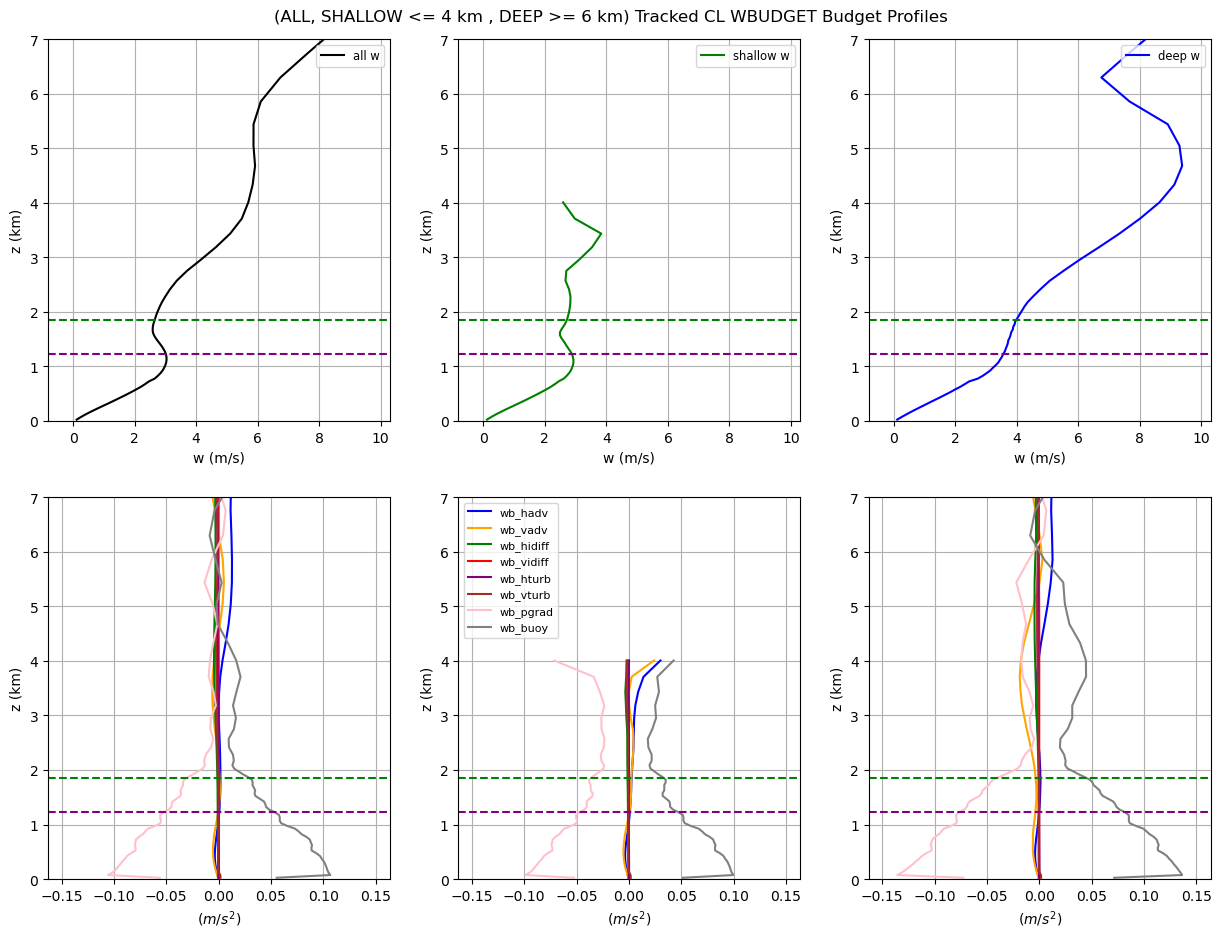

In [285]:
type1='CL'
PlotBudgetProfiles(
    type1=type1,
    vars = [
    'w',
    'wb_hadv',
    'wb_vadv',
    'wb_hidiff',
    'wb_vidiff',
    'wb_hturb',
    'wb_vturb',
    'wb_pgrad',
    'wb_buoy'],
    var_unit='m/s',
    budget_unit=r'$m/s^2$',
    title_tag=type1,
    output_filename=dir + 'Project_Algorithms/plots/CL_Tracked_WBUDGET_profile.jpg',
    colors=[
        'black', 'blue', 'orange', 'green', 'red',
        'purple', 'brown', 'pink', 'grey', 'cyan'
    ]
)


Currently on cloud type: all
Currently on cloud type: shallow
Currently on cloud type: deep
(2.726009852084962, 16.51815339415186)
(0.0, 7.0)
(-0.021193192654862806, 0.024212234024008652)
(0.0, 7.0)


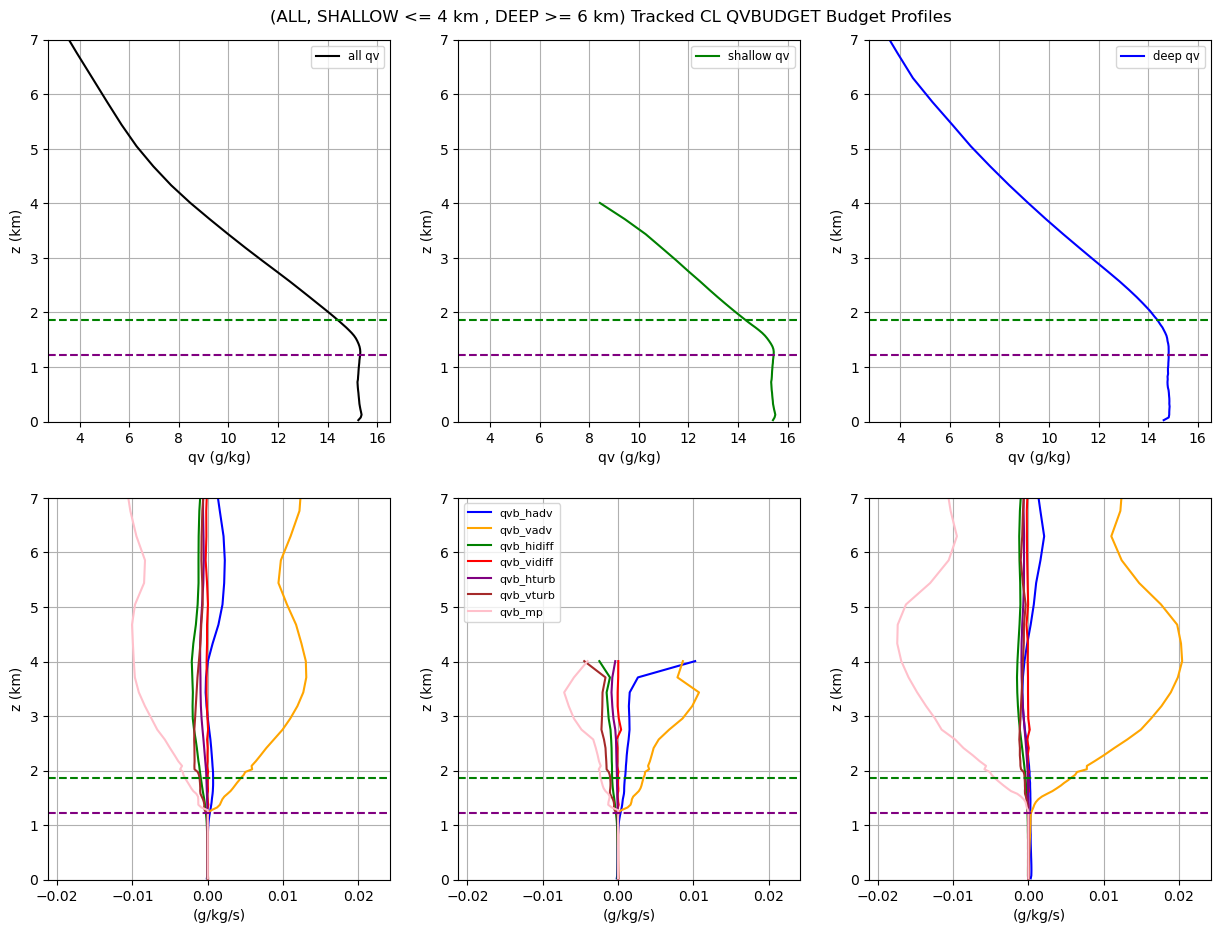

In [286]:
type1='CL'
PlotBudgetProfiles(
    type1=type1,
    vars = [
        'qv',
        'qvb_hadv',
        'qvb_vadv',
        'qvb_hidiff',
        'qvb_vidiff',
        'qvb_hturb',
        'qvb_vturb',
        'qvb_mp'
    ],
    var_unit='g/kg',
    budget_unit='g/kg/s',
    title_tag=type1,
    output_filename=dir + 'Project_Algorithms/plots/CL_Tracked_WBUDGET_profile.jpg',
    colors=[
        'black', 'blue', 'orange', 'green', 'red',
        'purple', 'brown', 'pink', 'grey', 'cyan'
    ],
    min_value=0
)


Currently on cloud type: all
Currently on cloud type: shallow
Currently on cloud type: deep
(302.36303704753203, 370.6752437366689)
(0.0, 17.586249999981373)
(-0.20740120670451498, 0.12748804755587662)
(0.0, 17.586249999981373)


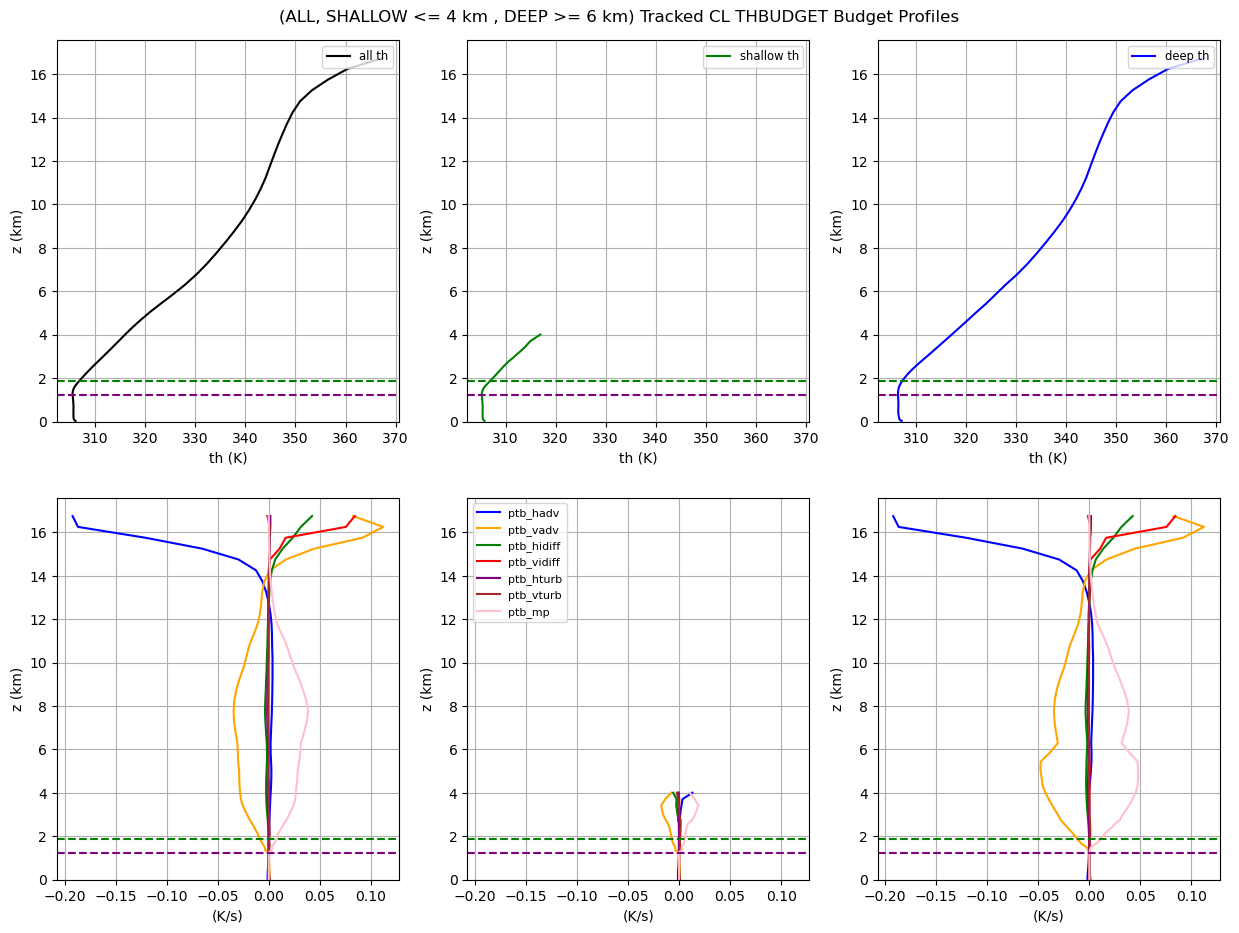

In [205]:
type1='CL'
PlotBudgetProfiles(
    type1=type1,
    vars = [
        'th',
        'ptb_hadv',
        'ptb_vadv',
        'ptb_hidiff',
        'ptb_vidiff',
        'ptb_hturb',
        'ptb_vturb',
        'ptb_mp'
    ],
    var_unit='K',
    budget_unit='K/s',
    title_tag=type1,
    output_filename=dir + 'Project_Algorithms/plots/CL_Tracked_WBUDGET_profile.jpg',
    colors=[
        'black', 'blue', 'orange', 'green', 'red',
        'purple', 'brown', 'pink', 'grey', 'cyan'
    ]
)


Currently on cloud type: all
Currently on cloud type: shallow
Currently on cloud type: deep
(-0.6808862521237473, 12.347881606961437)
(0.0, 17.586249999981373)
(-0.596888161390149, 0.2951725626703013)
(0.0, 17.586249999981373)


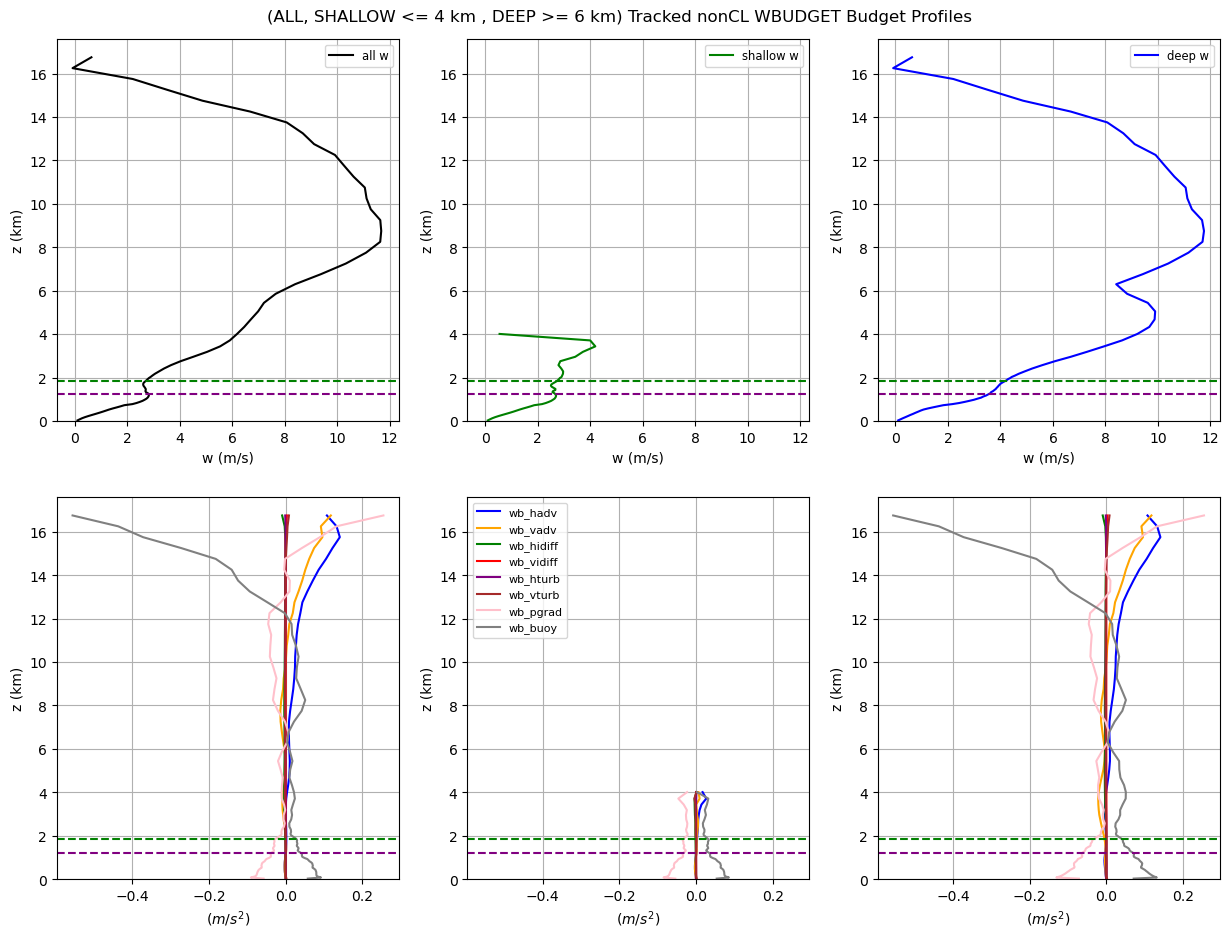

In [206]:
type1='nonCL'
PlotBudgetProfiles(
    type1=type1,
    vars = [
    'w',
    'wb_hadv',
    'wb_vadv',
    'wb_hidiff',
    'wb_vidiff',
    'wb_hturb',
    'wb_vturb',
    'wb_pgrad',
    'wb_buoy'],
    var_unit='m/s',
    budget_unit=r'$m/s^2$',
    title_tag=type1,
    output_filename=dir + 'Project_Algorithms/plots/CL_Tracked_WBUDGET_profile.jpg',
    colors=[
        'black', 'blue', 'orange', 'green', 'red',
        'purple', 'brown', 'pink', 'grey', 'cyan'
    ],
    min_value=0
)


Currently on cloud type: all
Currently on cloud type: shallow
Currently on cloud type: deep
(2.837146208473186, 17.31308803133002)
(0.0, 7.0)
(-0.022845301231432837, 0.02588585123275831)
(0.0, 7.0)


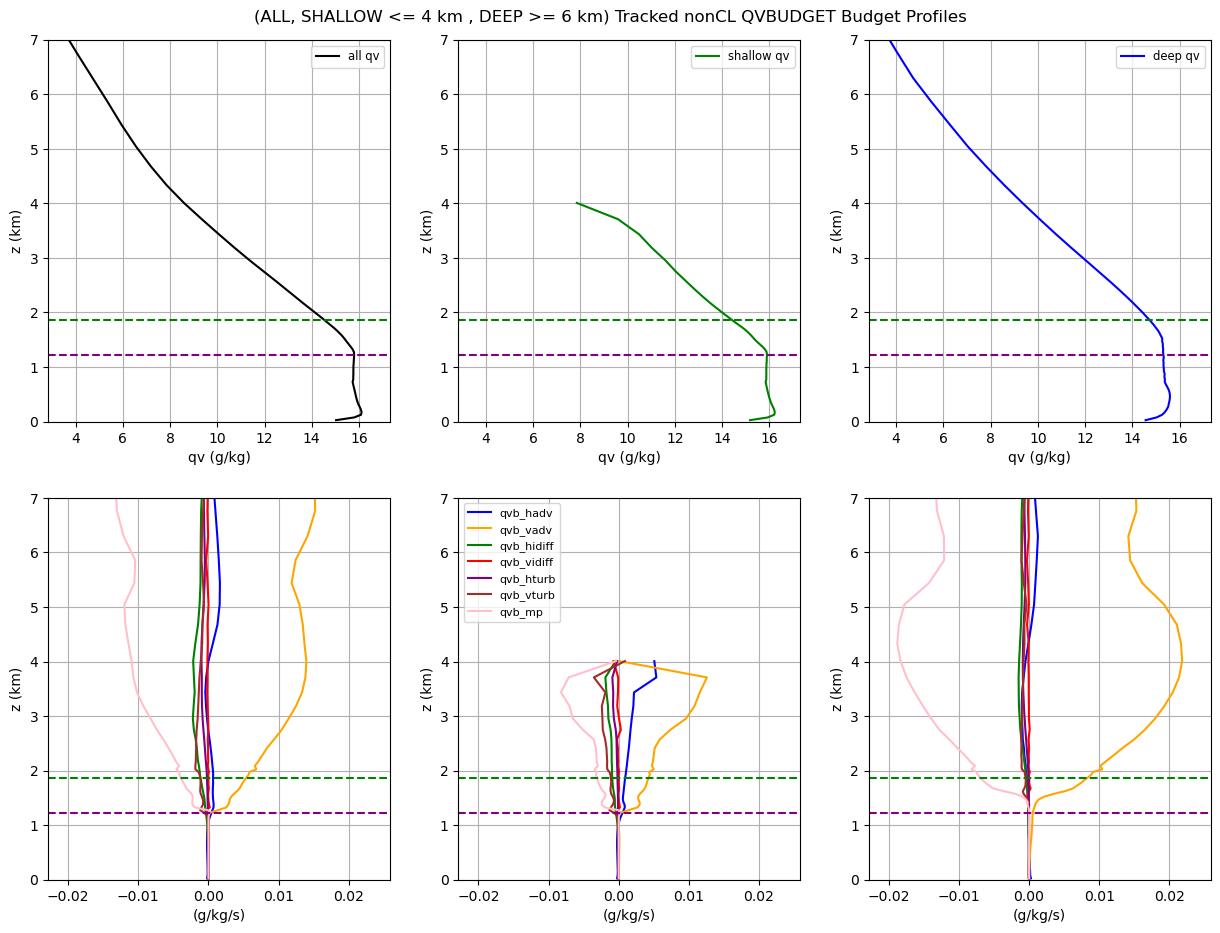

In [288]:
type1='nonCL'
PlotBudgetProfiles(
    type1=type1,
    vars = [
        'qv',
        'qvb_hadv',
        'qvb_vadv',
        'qvb_hidiff',
        'qvb_vidiff',
        'qvb_hturb',
        'qvb_vturb',
        'qvb_mp'
    ],
    var_unit='g/kg',
    budget_unit='g/kg/s',
    title_tag=type1,
    output_filename=dir + 'Project_Algorithms/plots/CL_Tracked_WBUDGET_profile.jpg',
    colors=[
        'black', 'blue', 'orange', 'green', 'red',
        'purple', 'brown', 'pink', 'grey', 'cyan'
    ]
)


Currently on cloud type: all
Currently on cloud type: shallow
Currently on cloud type: deep
(302.2071491393224, 333.26302951494387)
(0.0, 7.0)
(-0.06285688821081298, 0.06284711145461194)
(0.0, 7.0)


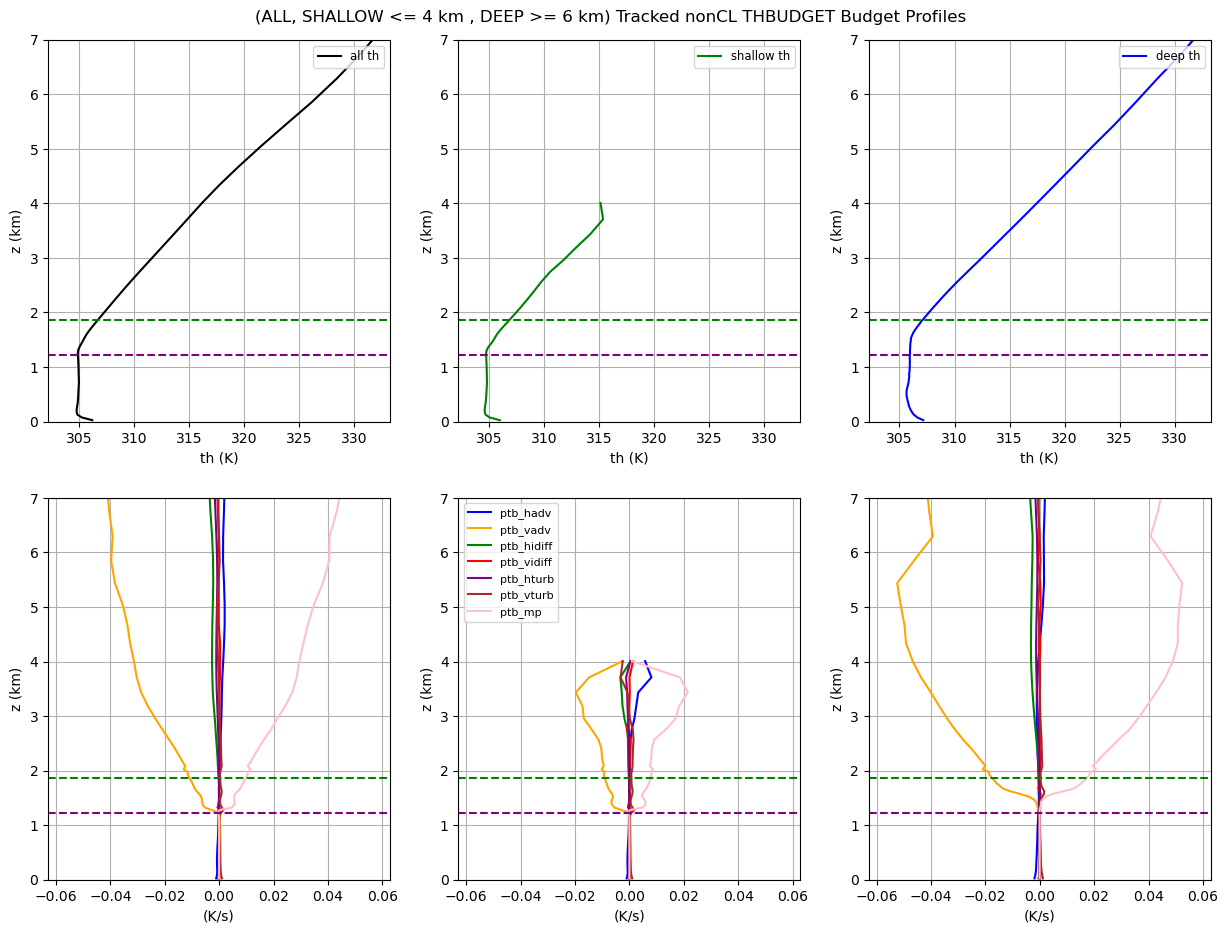

In [287]:
type1='nonCL'
PlotBudgetProfiles(
    type1=type1,
    vars = [
        'th',
        'ptb_hadv',
        'ptb_vadv',
        'ptb_hidiff',
        'ptb_vidiff',
        'ptb_hturb',
        'ptb_vturb',
        'ptb_mp'
    ],
    var_unit='K',
    budget_unit='K/s',
    title_tag=type1,
    output_filename=dir + 'Project_Algorithms/plots/CL_Tracked_WBUDGET_profile.jpg',
    colors=[
        'black', 'blue', 'orange', 'green', 'red',
        'purple', 'brown', 'pink', 'grey', 'cyan'
    ]
)


In [209]:
#CL minus nonCL

In [210]:
#Produced averaged profiles for plotting
# def averaged_profiles(var):
#     profile=globals()[f"profile_{var}"]

#     out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
#     out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
#     return out_var
def average_difference(array1, array2):
    out_var_one=averaged_profiles(array1)
    out_var_two=averaged_profiles(array2)

    #masking out non matches
    second_col_one = out_var_one[:, 1]
    second_col_two = out_var_two[:, 1]
    mask_one = np.isin(second_col_one, second_col_two)
    mask_two = np.isin(second_col_two, second_col_one)
    
    out_var_one = out_var_one.copy()[mask_one]
    out_var_two = out_var_two.copy()[mask_two]
    
    diff=(out_var_one[:,0]-out_var_two[:,0])
    zs=out_var_one[:,1]

    out_profile=np.zeros((len(diff),2))

    out_profile[:,0]=diff;out_profile[:,1]=zs;
    return out_profile

currently on type all
currently on type shallow
currently on type deep
(-2.0224954341565584, 2.1947911498712167)
(0.0, 17.586249999981373)
(-0.052059650677256285, 0.04953013141738716)
(0.0, 17.586249999981373)


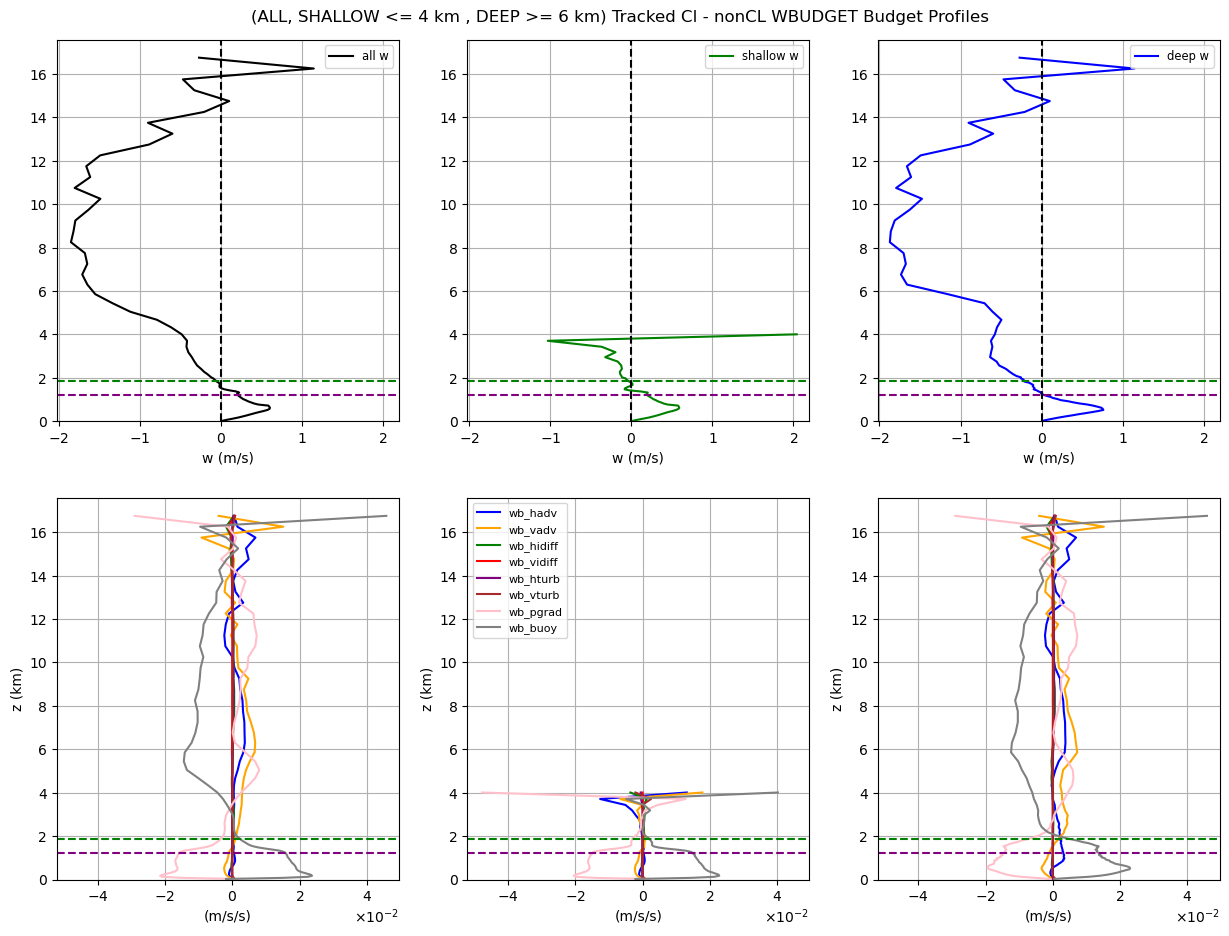

In [211]:
#CL-nonCL W BUDGETS
####################################################################
dim='1km'

#Uses Plotting Function 
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
plt.subplots_adjust(top=0.95)

fig.suptitle(f"(ALL, SHALLOW <= 4 km , DEEP >= 6 km) Tracked Cl - nonCL WBUDGET Budget Profiles")
ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()

####################################################################
for type in ["all","shallow","deep"]:
    print(f'currently on type {type}')

    #Plotting function
    def plotting(out_var,axis,label,color):
        axis.plot(out_var[:,0],out_var[:,1],label=label,color=color)
        axis.grid(True)
    
    #Uses Averaged_Profiles Function
    vars = [
    'w',
    'wb_hadv',
    'wb_vadv',
    'wb_hidiff',
    'wb_vidiff',
    'wb_hturb',
    'wb_vturb',
    'wb_pgrad',
    'wb_buoy'
]

    #LOADING IN DATA
    for var in vars:
        globals()[f"profile_{var}1"] = globals()[f"CL_{type.upper()}_profile_array_{var.upper()}"]
        
        
    #LOADING IN DATA
    for var in vars:
        globals()[f"profile_{var}2"] = globals()[f"nonCL_{type.upper()}_profile_array_{var.upper()}"]
    
    colors = [
    'black',    
    'blue',     
    'orange',   
    'green',    
    'red',      
    'purple',   
    'brown',    
    'pink',     
    'grey',
    'cyan'
]

    for var in vars:
        globals()[f"out_{var}"]=average_difference(globals()[f"profile_{var}1"],globals()[f"profile_{var}2"])
        # globals()[f"out_{var}"]=averaged_profiles(var)
        

    if type=='all':
        axis=ax1
        plotting(out_w,axis,label=f'{type} ' + vars[0],color=colors[0])
        # axis.set_ylim(bottom=0,top=4.25)
        axis.set_xlabel('w (m/s)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax4
    if type=='shallow':
        axis=ax2
        plotting(out_w,axis,label=f'{type} ' + vars[0],color=colors[3])
        # axis.set_ylim(bottom=0,top=4.25)
        axis.set_xlabel('w (m/s)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax5
    if type=='deep':
        axis=ax3
        plotting(out_w,axis,label=f'{type} ' + vars[0],color=colors[1])
        # axis.set_ylim(bottom=0,top=4.25)
        axis.set_xlabel('w (m/s)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax6
    for var,xlabel,color in zip(vars[1:],vars[1:],colors[1:]):
        plotting(globals()[f"out_{var}"],axis,label=xlabel,color=color)
        # axis.set_ylim(bottom=0,top=4.25)
        axis.set_ylabel('z (km)');
        axis.set_xlabel('(m/s/s)')
        if type in ['shallow']:
            axis.legend(loc='upper left', fontsize=8); #add legend

#LIMITING Y AXIS
for ax in [ax1,ax2,ax3,ax4,ax5,ax6]:
    ax.set_ylim(bottom=0)
    #LIMITING YAXIS TO BELOW 7 KM
    if limit_y==True: 
        limit_axes_to_y(ax,y_min=0, y_max=7)   
 
#FIXING XAXES
fix_x_limits([ax1, ax2, ax3]);fix_y_limits([ax1, ax2, ax3])
fix_x_limits([ax4, ax5, ax6]);fix_y_limits([ax4, ax5, ax6])

    
#SCIENTIFIC NOTATION
apply_scientific_notation([ax1, ax2, ax3,ax4,ax5,ax6])

# #MEAN LFC 
# for axis in [ax1,ax4]:
#     axis.axhline(np.mean((mean_LFC(ALL_out_arr), mean_LFC(ALL_save_nz))),color='blue',linestyle='dashed')
# for axis in [ax2,ax5]:
#     axis.axhline(np.mean((mean_LFC(SHALLOW_out_arr), mean_LFC(SHALLOW_save_nz))),color='blue',linestyle='dashed')
# for axis in [ax3,ax6]:
#     axis.axhline(np.mean((mean_LFC(DEEP_out_arr), mean_LFC(DEEP_save_nz))),color='blue',linestyle='dashed')

#MEAN CLOUD BASE
axs = fig.get_axes()
ax1, ax2, ax3, ax4, ax5, ax6 = axs
for axis in [ax1,ax2,ax3,ax4,ax5,ax6]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')
    axis.axhline(MeanLFC/1000,color='green',linestyle='dashed')

#MIDDLE LINE
for axis in [ax1,ax2,ax3]:
    axis.axvline(0,color='k',linestyle='dashed')


#save plot
if dim=='1km':
    plt.savefig(dir+f'Project_Algorithms/plots/CLminusnonCL_Tracked_WBUDGET_profile.jpg', bbox_inches='tight', dpi=300) 
#- Limited

currently on type all
currently on type shallow
currently on type deep
(-0.8800555470134787, 0.7149320983303848)
(0.0, 7.0)
(-0.006754957023247243, 0.009890837897330584)
(0.0, 7.0)


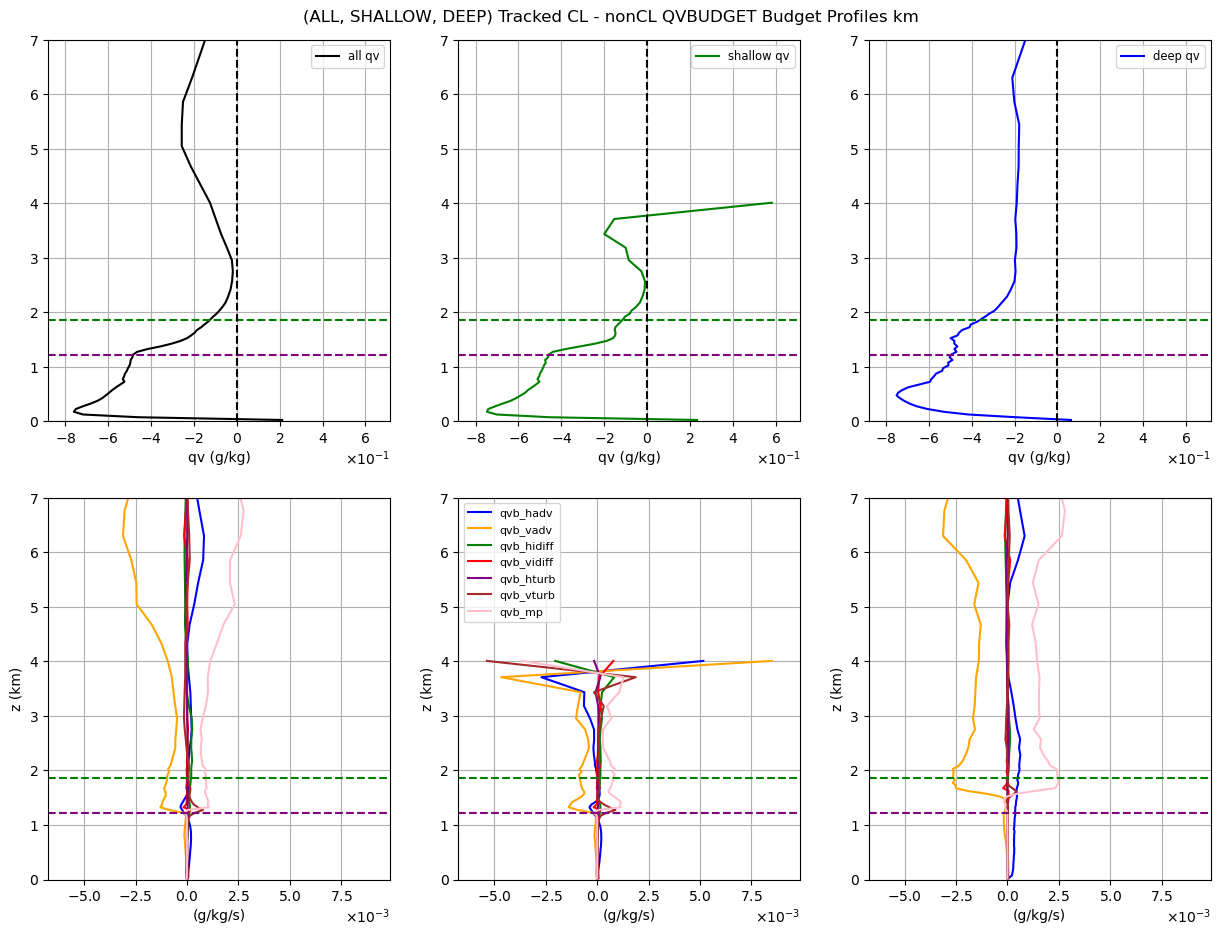

In [289]:
#CL - nonCL QV BUDGETS

import h5py
#Produced averaged profiles for plotting
####################################################################
dim='1km'

#Uses Plotting Function 
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
plt.subplots_adjust(top=0.95)

fig.suptitle(f"(ALL, SHALLOW, DEEP) Tracked CL - nonCL QVBUDGET Budget Profiles km")
ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()

####################################################################
for type in ["all","shallow","deep"]:
    print(f'currently on type {type}')
        
    #Plotting function
    def plotting(out_var,axis,label,color):
        axis.plot(out_var[:,0],out_var[:,1],label=label,color=color)
        axis.grid(True)
    
    #Uses Averaged_Profiles Function
    vars = [
        'qv',
        'qvb_hadv',
        'qvb_vadv',
        'qvb_hidiff',
        'qvb_vidiff',
        'qvb_hturb',
        'qvb_vturb',
        'qvb_mp'
    ]

    #LOADING IN DATA
    for var in vars:
        globals()[f"profile_{var}1"] = globals()[f"CL_{type.upper()}_profile_array_{var.upper()}"]
        
    #LOADING IN DATA
    for var in vars:
        globals()[f"profile_{var}2"] = globals()[f"nonCL_{type.upper()}_profile_array_{var.upper()}"]
    
    colors = [
    'black',    
    'blue',     
    'orange',   
    'green',    
    'red',      
    'purple',   
    'brown',    
    'pink',     
    'grey',
    'cyan'
]

    for var in vars:
        globals()[f"out_{var}"]=average_difference(globals()[f"profile_{var}1"],globals()[f"profile_{var}2"])
        globals()[f"out_{var}"][:,0]*=1000
        

    if type=='all':
        axis=ax1
        plotting(out_qv,axis,label=f'{type} ' + vars[0],color=colors[0])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('qv (g/kg)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax4
    elif type=='shallow':
        axis=ax2
        plotting(out_qv,axis,label=f'{type} ' + vars[0],color=colors[3])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('qv (g/kg)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax5
    elif type=='deep':
        axis=ax3
        plotting(out_qv,axis,label=f'{type} ' + vars[0],color=colors[1])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('qv (g/kg)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax6
    for var,xlabel,color in zip(vars[1:],vars[1:],colors[1:]):
        plotting(globals()[f"out_{var}"],axis,label=xlabel,color=color)
        # axis.set_ylim(bottom=0,top=16)
        axis.set_ylabel('z (km)');
        axis.set_xlabel('(g/kg/s)')
        if type=='shallow':
            axis.legend(loc='upper left', fontsize=8) #add legend

#LIMITING Y AXIS
for ax in [ax1,ax2,ax3,ax4,ax5,ax6]:
    ax.set_ylim(bottom=0)
    #LIMITING YAXIS TO BELOW 7 KM
    if limit_y==True: 
        limit_axes_to_y(ax,y_min=0, y_max=7)   

#FIXING XAXES
fix_x_limits([ax1, ax2, ax3]);fix_y_limits([ax1, ax2, ax3])
fix_x_limits([ax4, ax5, ax6]);fix_y_limits([ax4, ax5, ax6])

# #MEAN LFC 
# for axis in [ax1,ax4]:
#     axis.axhline(np.mean((mean_LFC(ALL_out_arr), mean_LFC(ALL_save_nz))),color='blue',linestyle='dashed')
# for axis in [ax2,ax5]:
#     axis.axhline(np.mean((mean_LFC(SHALLOW_out_arr), mean_LFC(SHALLOW_save_nz))),color='blue',linestyle='dashed')
# for axis in [ax3,ax6]:
#     axis.axhline(np.mean((mean_LFC(DEEP_out_arr), mean_LFC(DEEP_save_nz))),color='blue',linestyle='dashed')

#MEAN CLOUD BASE
axs = fig.get_axes()
ax1, ax2, ax3, ax4, ax5, ax6 = axs
for axis in [ax1,ax2,ax3,ax4,ax5,ax6]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')
    axis.axhline(MeanLFC/1000,color='green',linestyle='dashed')

    
#SCIENTIFIC NOTATION
apply_scientific_notation([ax1,ax2,ax3,ax4, ax5, ax6])

#MIDDLE LINE
for axis in [ax1,ax2,ax3]:
    axis.axvline(0,color='k',linestyle='dashed')

#save plot
if dim=='1km':
    plt.savefig(dir+f'Project_Algorithms/plots/ClminusnonCL_Tracked_QVBUDGET_profile.jpg', bbox_inches='tight', dpi=300) 
#limited

currently on type all
currently on type shallow
currently on type deep
(-0.9639887600143794, 3.371240052892395)
(0.0, 17.586249999981373)
(-0.03620314054449343, 0.028608102203425398)
(0.0, 17.586249999981373)


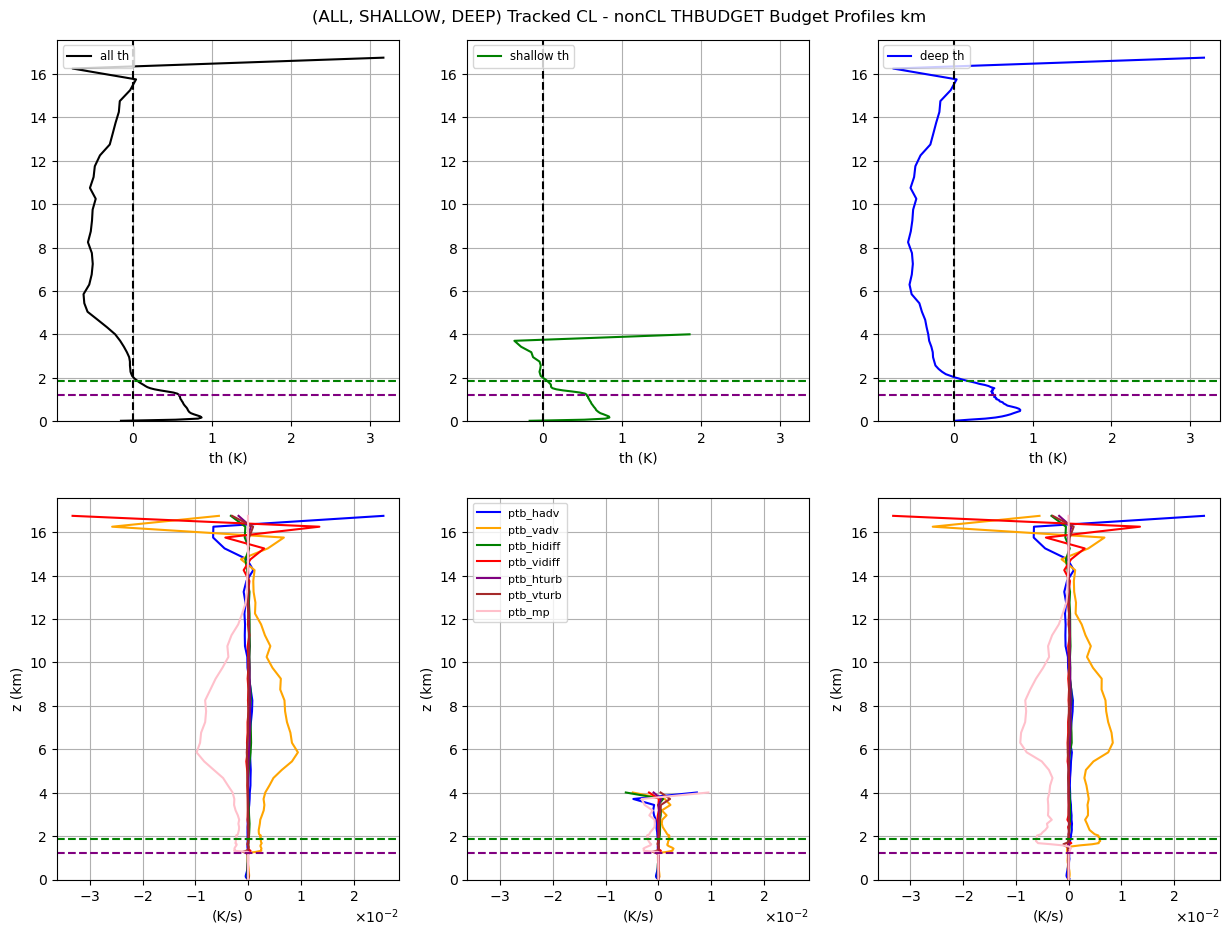

In [213]:
#CL - nonCL TH BUDGETS

import h5py
####################################################################
dim='1km'

#Uses Plotting Function 
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
plt.subplots_adjust(top=0.95)

fig.suptitle(f"(ALL, SHALLOW, DEEP) Tracked CL - nonCL THBUDGET Budget Profiles km")
ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()

####################################################################
for type in ["all","shallow","deep"]:
    print(f'currently on type {type}')
        
    #Plotting function
    def plotting(out_var,axis,label,color):
        axis.plot(out_var[:,0],out_var[:,1],label=label,color=color)
        axis.grid(True)
    
    #Uses Averaged_Profiles Function
    vars = [
        'th',
        'ptb_hadv',
        'ptb_vadv',
        'ptb_hidiff',
        'ptb_vidiff',
        'ptb_hturb',
        'ptb_vturb',
        'ptb_mp'
    ]

    #LOADING IN DATA
    for var in vars:
        globals()[f"profile_{var}1"] = globals()[f"CL_{type.upper()}_profile_array_{var.upper()}"]
        
    #LOADING IN DATA
    for var in vars:
        globals()[f"profile_{var}2"] = globals()[f"nonCL_{type.upper()}_profile_array_{var.upper()}"]
    
    colors = [
    'black',    
    'blue',     
    'orange',   
    'green',    
    'red',      
    'purple',   
    'brown',    
    'pink',     
    'grey',
    'cyan'
]

    for var in vars:
        globals()[f"out_{var}"]=average_difference(globals()[f"profile_{var}1"],globals()[f"profile_{var}2"])
        # globals()[f"out_{var}"]=averaged_profiles(var)

    if type=='all':
        axis=ax1
        plotting(out_th,axis,label=f'{type} ' + vars[0],color=colors[0])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('th (K)')
        axis.legend(loc='upper left', fontsize='small'); #add legend
        axis=ax4
    elif type=='shallow':
        axis=ax2
        plotting(out_th,axis,label=f'{type} ' + vars[0],color=colors[3])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('th (K)')
        axis.legend(loc='upper left', fontsize='small'); #add legend
        axis=ax5
    elif type=='deep':
        axis=ax3
        plotting(out_th,axis,label=f'{type} ' + vars[0],color=colors[1])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('th (K)')
        axis.legend(loc='upper left', fontsize='small'); #add legend
        axis=ax6
    for var,xlabel,color in zip(vars[1:],vars[1:],colors[1:]):
        plotting(globals()[f"out_{var}"],axis,label=xlabel,color=color)
        # axis.set_ylim(bottom=0,top=16)
        axis.set_ylabel('z (km)');
        axis.set_xlabel('(K/s)')
        if type=='shallow':
            axis.legend(loc='upper left', fontsize=8); #add legend

#LIMITING Y AXIS
for ax in [ax1,ax2,ax3,ax4,ax5,ax6]:
    ax.set_ylim(bottom=0)
    #LIMITING YAXIS TO BELOW 7 KM
    if limit_y==True: 
        limit_axes_to_y(ax,y_min=0, y_max=7)   

#FIXING XAXES
fix_x_limits([ax1, ax2, ax3]);fix_y_limits([ax1, ax2, ax3])
fix_x_limits([ax4, ax5, ax6]);fix_y_limits([ax4, ax5, ax6])

# #MEAN LFC 
# for axis in [ax1,ax4]:
#     axis.axhline(np.mean((mean_LFC(ALL_out_arr), mean_LFC(ALL_save_nz))),color='blue',linestyle='dashed')
# for axis in [ax2,ax5]:
#     axis.axhline(np.mean((mean_LFC(SHALLOW_out_arr), mean_LFC(SHALLOW_save_nz))),color='blue',linestyle='dashed')
# for axis in [ax3,ax6]:
#     axis.axhline(np.mean((mean_LFC(DEEP_out_arr), mean_LFC(DEEP_save_nz))),color='blue',linestyle='dashed')

#MEAN CLOUD BASE
axs = fig.get_axes()
ax1, ax2, ax3, ax4, ax5, ax6 = axs
for axis in [ax1,ax2,ax3,ax4,ax5,ax6]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')
    axis.axhline(MeanLFC/1000,color='green',linestyle='dashed')


#SCIENTIFIC NOTATION
apply_scientific_notation([ax1, ax2, ax3,ax4,ax5,ax6])

#MIDDLE LINE
for axis in [ax1,ax2,ax3]:
    axis.axvline(0,color='k',linestyle='dashed')

#save plot
if dim=='1km':
    plt.savefig(dir+f'Project_Algorithms/plots/CLminusnonCL_Tracked_THBUDGET_profile.jpg', bbox_inches='tight', dpi=300) 
#limited

In [214]:
#SBZ vs NONSBZ
################################################################

In [290]:
data_type="Tracked_Properties"
type1='SBZ';type2='nonSBZ'
dir3=dir+'Project_Algorithms/Tracked_Profiles/OUTPUT_FILES/'
filePath=dir3+f"{data_type}_"+f"{type1}_{type2}_tracked_profiles_{res}_{t_res}_{Np_str}.h5"
key_list=[]
with h5py.File(filePath, 'r') as h5f:
    for key in h5f.keys():
        globals()[key] = h5f[key][:]
        if '_squares' not in key:
            key_list.append(key)
        # print(key)

#CALCULATING STANDARD DEVIATION
for key in key_list:
    # globals()[key+f"_SE"]=ProfileStandardError(globals()[key],globals()[key+f"_squares"])
    globals()[key+f"_SE"]=ProfileStandardDeviation(globals()[key],globals()[key+f"_squares"])

#MULTIPLING QV BY 1000
for key in key_list:
    if 'Q' in key:
        globals()[key][:,0]*=1000
        globals()[key+f"_SE"][:,0]*=1000
    # print(key)

ValueError: operands could not be broadcast together with shapes (29,) (78,) (29,) 

In [291]:
#*#*#
#IF SE NOT AVAILABLE, MAKE DUMMY VARIABLES
factor=1
for key in key_list:
    dummy=globals()[key].copy()
    dummy[:,0]=np.zeros(len(dummy[:,0]))
    dummy=dummy[dummy[:,1]>1]
    globals()[key+f"_SE"]=dummy

In [292]:
#NEEDED TO PLOT THE CORRECT DATA #*#*
data_type="Tracked_WQVTH_Budgets"

type1='SBZ';type2='nonSBZ'
dir3=dir+'Project_Algorithms/Tracked_Profiles/OUTPUT_FILES/'
filePath=dir3+f"{data_type}_"+f"{type1}_{type2}_tracked_profiles_{res}_{t_res}_{Np_str}.h5"
key_list=[]
with h5py.File(filePath, 'r') as h5f:
    for key in h5f.keys():
        globals()[key] = h5f[key][:]
        if '_squares' not in key:
            key_list.append(key)

#CALCULATING STANDARD DEVIATION
for key in key_list:
    # globals()[key+f"_SE"]=ProfileStandardError(globals()[key],globals()[key+f"_squares"])
    globals()[key+f"_SE"]=ProfileStandardDeviation(globals()[key],globals()[key+f"_squares"])

#MULTIPLING QV BY 1000
for key in key_list:
    if 'QVB' in key:
        globals()[key][:,0]*=1000
        globals()[key+f"_SE"][:,0]*=1000

ValueError: operands could not be broadcast together with shapes (29,) (78,) (29,) 

In [293]:
#*#*#
#IF SE NOT AVAILABLE, MAKE DUMMY VARIABLES
factor=1
for key in key_list:
    dummy=globals()[key].copy()
    dummy[:,0]=np.zeros(len(dummy[:,0]))
    dummy=dummy[dummy[:,1]>1]
    globals()[key+f"_SE"]=dummy

Currently on cloud type: all
Currently on cloud type: shallow
Currently on cloud type: deep
(-1.1631195446973273, 10.5239673118133)
(0.0, 17.061249999981374)
(-0.41096746284056473, 0.17301695423330216)
(0.0, 17.061249999981374)


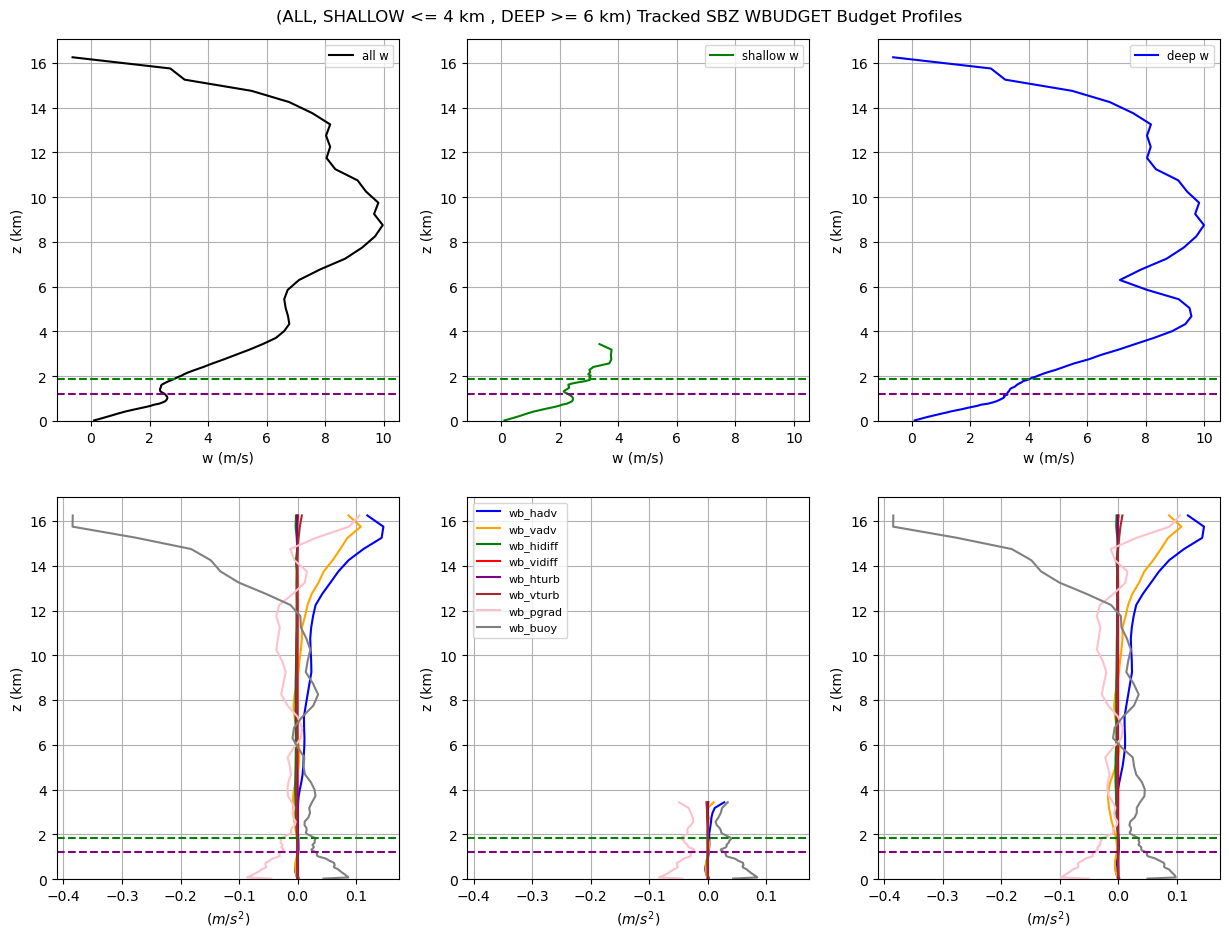

In [220]:
type1='SBZ'
PlotBudgetProfiles(
    type1=type1,
    vars = [
    'w',
    'wb_hadv',
    'wb_vadv',
    'wb_hidiff',
    'wb_vidiff',
    'wb_hturb',
    'wb_vturb',
    'wb_pgrad',
    'wb_buoy'],
    var_unit='m/s',
    budget_unit=r'$m/s^2$',
    title_tag=type1,
    output_filename=dir + 'Project_Algorithms/plots/CL_Tracked_WBUDGET_profile.jpg',
    colors=[
        'black', 'blue', 'orange', 'green', 'red',
        'purple', 'brown', 'pink', 'grey', 'cyan'
    ]
)



Currently on cloud type: all
Currently on cloud type: shallow
Currently on cloud type: deep
(2.6105338689502244, 17.383472457543917)
(0.0, 7.0)
(-0.021712042717738782, 0.024737147430060835)
(0.0, 7.0)


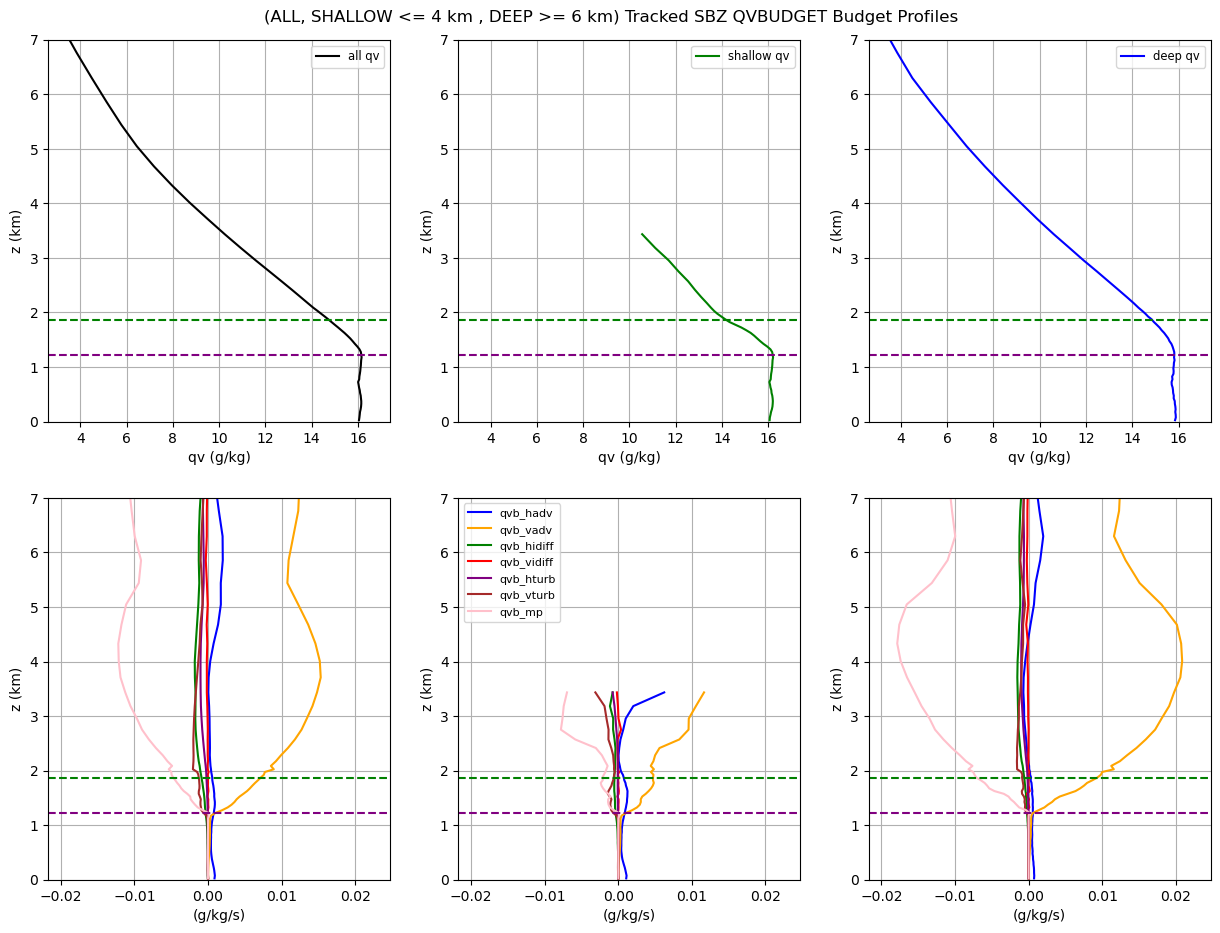

In [294]:
type1='SBZ'
PlotBudgetProfiles(
    type1=type1,
    vars = [
        'qv',
        'qvb_hadv',
        'qvb_vadv',
        'qvb_hidiff',
        'qvb_vidiff',
        'qvb_hturb',
        'qvb_vturb',
        'qvb_mp'
    ],
    var_unit='g/kg',
    budget_unit='g/kg/s',
    title_tag=type1,
    output_filename=dir + 'Project_Algorithms/plots/CL_Tracked_WBUDGET_profile.jpg',
    colors=[
        'black', 'blue', 'orange', 'green', 'red',
        'purple', 'brown', 'pink', 'grey', 'cyan'
    ],
    min_value=0
)


Currently on cloud type: all
Currently on cloud type: shallow
Currently on cloud type: deep
(301.6873170087292, 364.89160674449846)
(0.0, 17.061249999981374)
(-0.24312839653649473, 0.15509097861786245)
(0.0, 17.061249999981374)


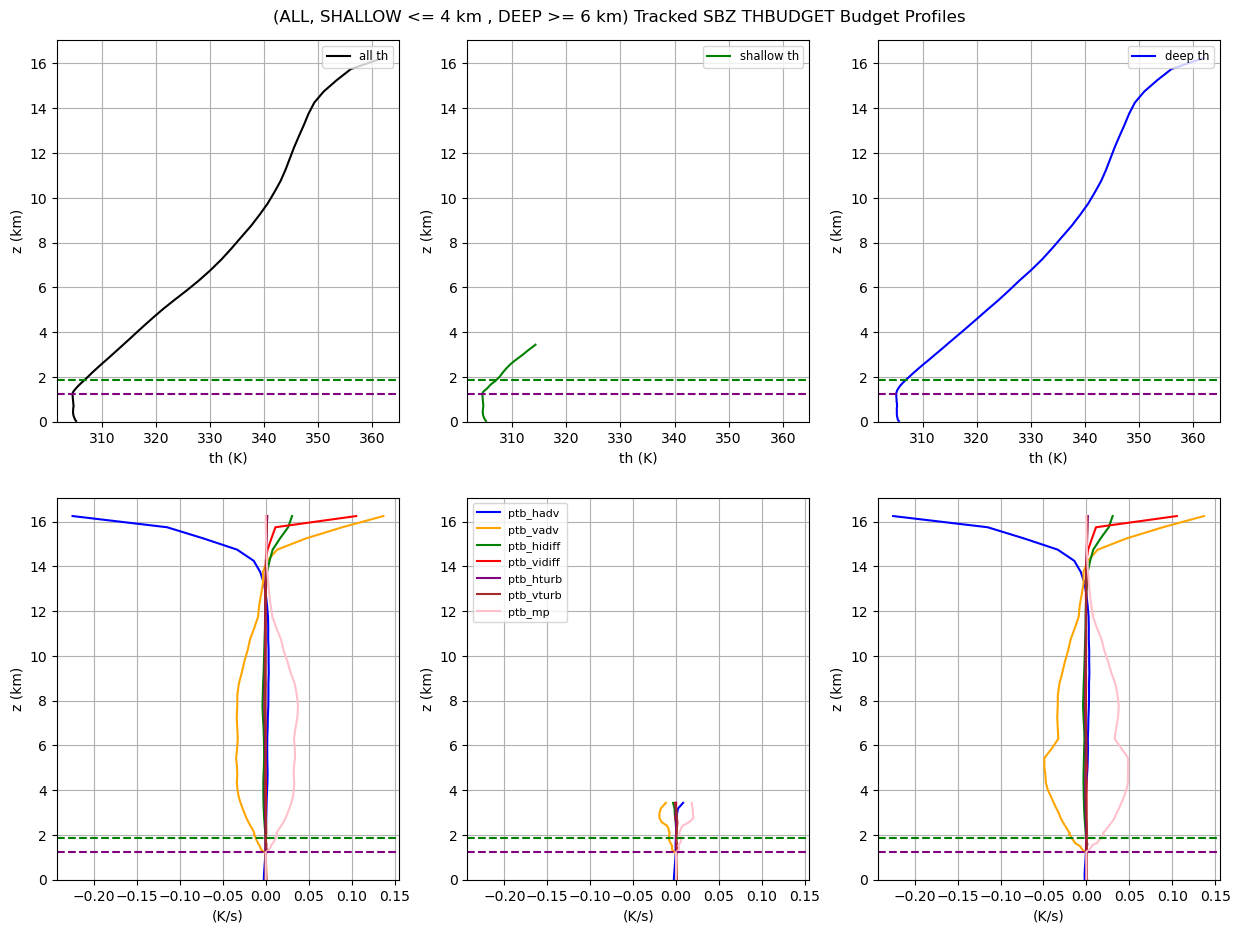

In [222]:
type1='SBZ'
PlotBudgetProfiles(
    type1=type1,
    vars = [
        'th',
        'ptb_hadv',
        'ptb_vadv',
        'ptb_hidiff',
        'ptb_vidiff',
        'ptb_hturb',
        'ptb_vturb',
        'ptb_mp'
    ],
    var_unit='K',
    budget_unit='K/s',
    title_tag=type1,
    output_filename=dir + 'Project_Algorithms/plots/CL_Tracked_WBUDGET_profile.jpg',
    colors=[
        'black', 'blue', 'orange', 'green', 'red',
        'purple', 'brown', 'pink', 'grey', 'cyan'
    ]
)


Currently on cloud type: all
Currently on cloud type: shallow
Currently on cloud type: deep
(-0.3740178533594171, 10.387717320054245)
(0.0, 17.586249999981373)
(-0.5515884412300527, 0.26456041645866873)
(0.0, 17.586249999981373)


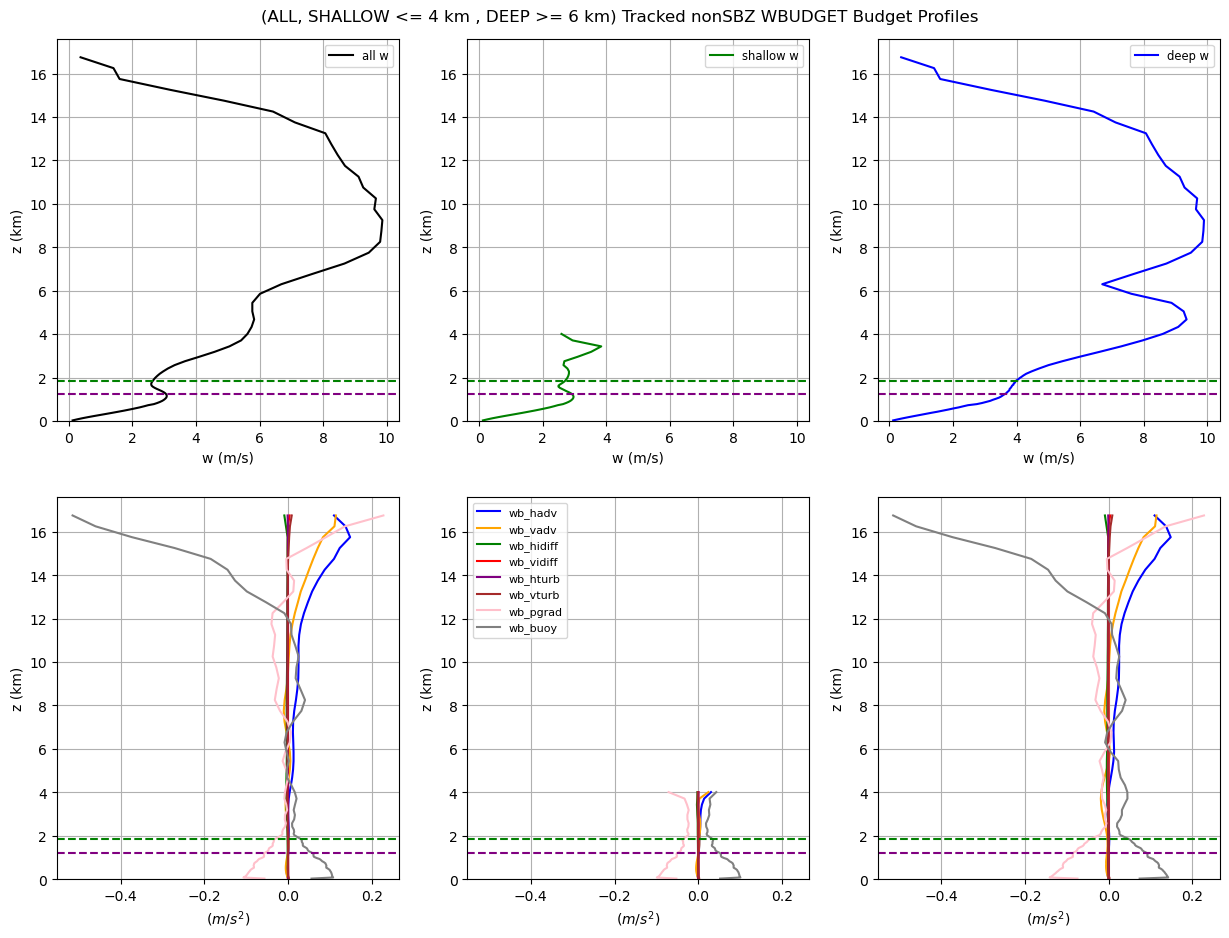

In [223]:
type1='nonSBZ'
PlotBudgetProfiles(
    type1=type1,
    vars = [
    'w',
    'wb_hadv',
    'wb_vadv',
    'wb_hidiff',
    'wb_vidiff',
    'wb_hturb',
    'wb_vturb',
    'wb_pgrad',
    'wb_buoy'],
    var_unit='m/s',
    budget_unit=r'$m/s^2$',
    title_tag=type1,
    output_filename=dir + 'Project_Algorithms/plots/CL_Tracked_WBUDGET_profile.jpg',
    colors=[
        'black', 'blue', 'orange', 'green', 'red',
        'purple', 'brown', 'pink', 'grey', 'cyan'
    ]
)



Currently on cloud type: all
Currently on cloud type: shallow
Currently on cloud type: deep
(2.7351292378169134, 16.481178282469774)
(0.0, 7.0)
(-0.021113011296572205, 0.024130959693666593)
(0.0, 7.0)


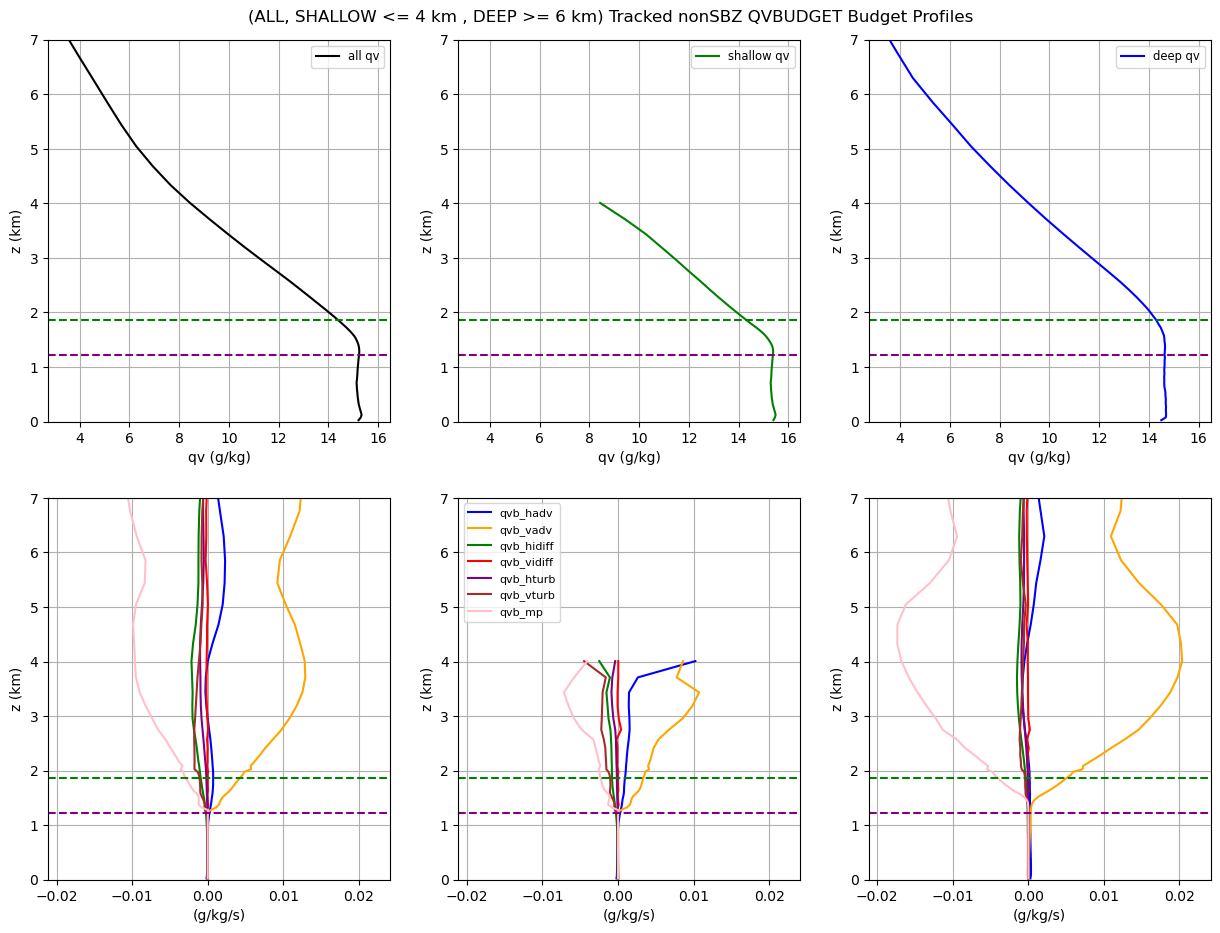

In [295]:
type1='nonSBZ'
PlotBudgetProfiles(
    type1=type1,
    vars = [
        'qv',
        'qvb_hadv',
        'qvb_vadv',
        'qvb_hidiff',
        'qvb_vidiff',
        'qvb_hturb',
        'qvb_vturb',
        'qvb_mp'
    ],
    var_unit='g/kg',
    budget_unit='g/kg/s',
    title_tag=type1,
    output_filename=dir + 'Project_Algorithms/plots/CL_Tracked_WBUDGET_profile.jpg',
    colors=[
        'black', 'blue', 'orange', 'green', 'red',
        'purple', 'brown', 'pink', 'grey', 'cyan'
    ],
    min_value=0
)


Currently on cloud type: all
Currently on cloud type: shallow
Currently on cloud type: deep
(302.46163366353034, 370.3681561207395)
(0.0, 17.586249999981373)
(-0.2118302666076461, 0.12237023311734664)
(0.0, 17.586249999981373)


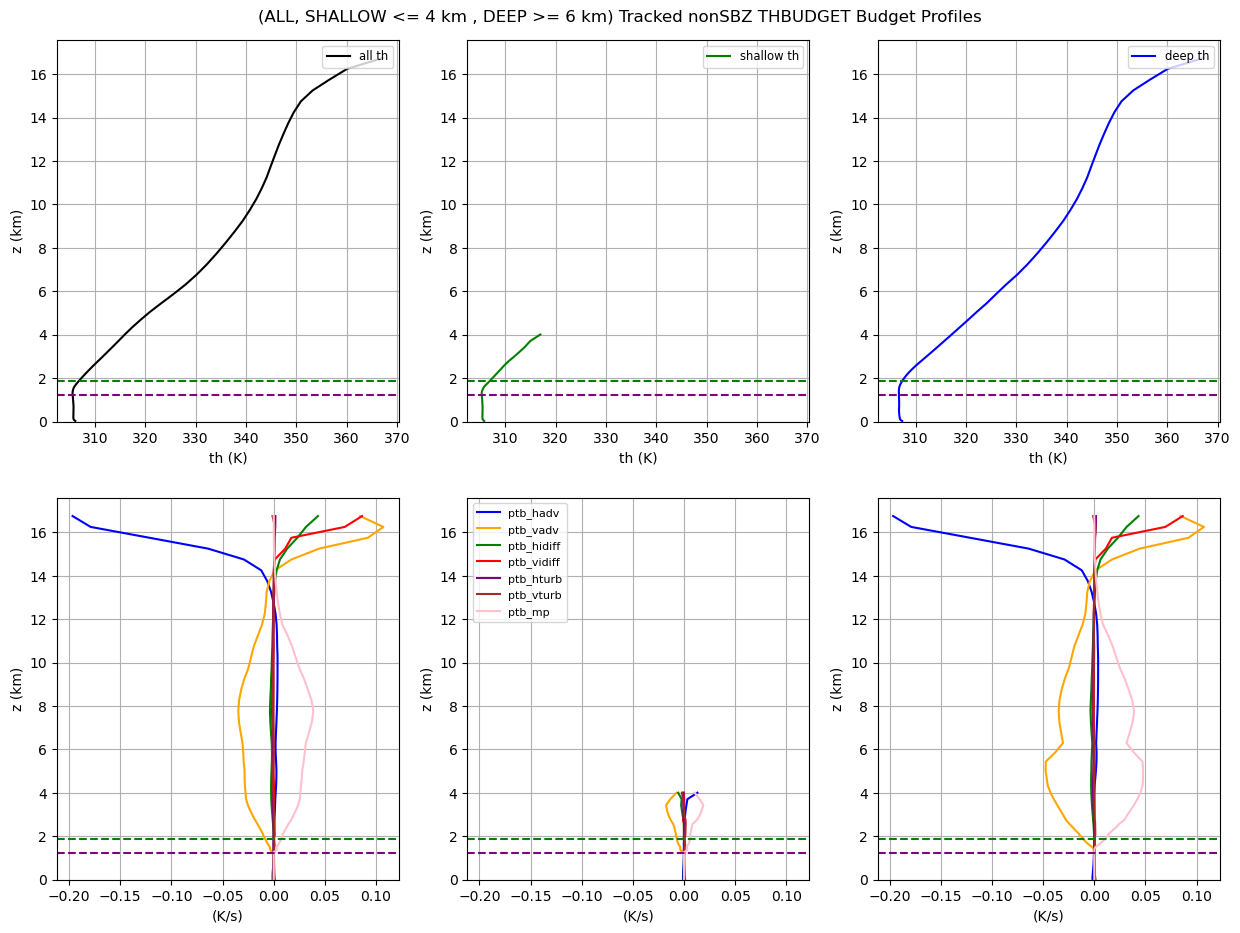

In [225]:
type1='nonSBZ'
PlotBudgetProfiles(
    type1=type1,
    vars = [
        'th',
        'ptb_hadv',
        'ptb_vadv',
        'ptb_hidiff',
        'ptb_vidiff',
        'ptb_hturb',
        'ptb_vturb',
        'ptb_mp'
    ],
    var_unit='K',
    budget_unit='K/s',
    title_tag=type1,
    output_filename=dir + 'Project_Algorithms/plots/CL_Tracked_WBUDGET_profile.jpg',
    colors=[
        'black', 'blue', 'orange', 'green', 'red',
        'purple', 'brown', 'pink', 'grey', 'cyan'
    ]
)


In [226]:
# SBZ minus nonSBZ

currently on type all
currently on type shallow
currently on type deep
(-2.1918122872278643, 1.271576452356872)
(0.0, 17.061249999981374)
(-0.049904645952885955, 0.08151690359535212)
(0.0, 17.061249999981374)


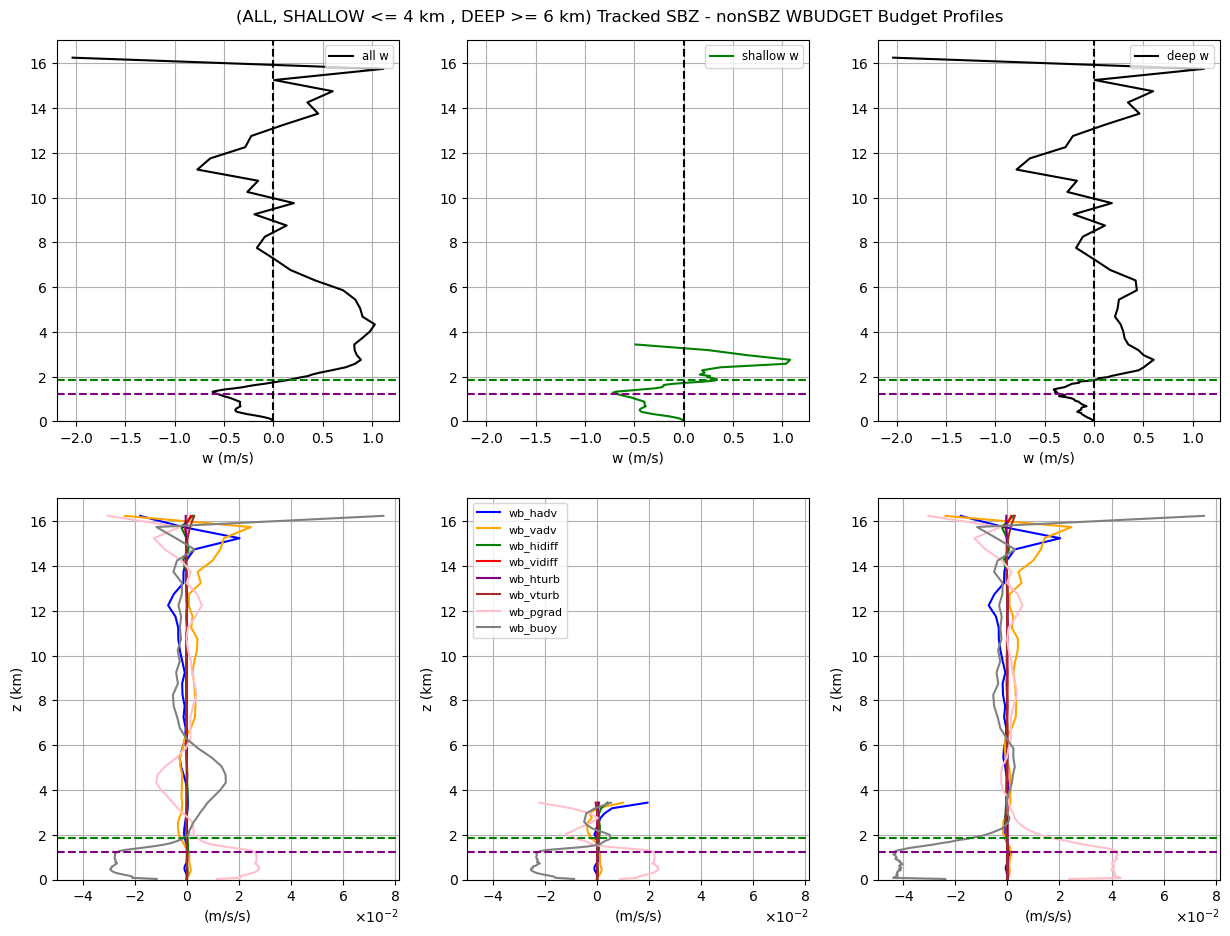

In [227]:
# SBZ minus nonSBZ W BUDGET
####################################################################
dim='1km'

#Uses Plotting Function 
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
plt.subplots_adjust(top=0.95)

fig.suptitle(f"(ALL, SHALLOW <= 4 km , DEEP >= 6 km) Tracked SBZ - nonSBZ WBUDGET Budget Profiles")
ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()

####################################################################
for type in ["all","shallow","deep"]:
    print(f'currently on type {type}')
    
    #Plotting function
    def plotting(out_var,axis,label,color):
        axis.plot(out_var[:,0],out_var[:,1],label=label,color=color)
        axis.grid(True)
    
    #Uses Averaged_Profiles Function
    vars = [
    'w',
    'wb_hadv',
    'wb_vadv',
    'wb_hidiff',
    'wb_vidiff',
    'wb_hturb',
    'wb_vturb',
    'wb_pgrad',
    'wb_buoy'
]

    for var in vars:
        globals()[f"profile_{var}1"] = globals()[f"SBZ_{type.upper()}_profile_array_{var.upper()}"]
    for var in vars:
        globals()[f"profile_{var}2"] = globals()[f"nonSBZ_{type.upper()}_profile_array_{var.upper()}"]
    
    colors = [
    'black',    
    'blue',     
    'orange',   
    'green',    
    'red',      
    'purple',   
    'brown',    
    'pink',     
    'grey',
    'cyan'
]

    for var in vars:
        globals()[f"out_{var}"]=average_difference(globals()[f"profile_{var}1"],globals()[f"profile_{var}2"])
        # globals()[f"out_{var}"]=averaged_profiles(var)
        

    if type=='all':
        axis=ax1
        plotting(out_w,axis,label=f'{type} ' + vars[0],color=colors[0])
        # axis.set_ylim(bottom=0,top=4.25)
        axis.set_xlabel('w (m/s)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax4
    if type=='shallow':
        axis=ax2
        plotting(out_w,axis,label=f'{type} ' + vars[0],color=colors[3])
        # axis.set_ylim(bottom=0,top=4.25)
        axis.set_xlabel('w (m/s)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax5
    if type=='deep':
        axis=ax3
        plotting(out_w,axis,label=f'{type} ' + vars[0],color=colors[0])
        # axis.set_ylim(bottom=0,top=4.25)
        axis.set_xlabel('w (m/s)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax6
    for var,xlabel,color in zip(vars[1:],vars[1:],colors[1:]):
        plotting(globals()[f"out_{var}"],axis,label=xlabel,color=color)
        # axis.set_ylim(bottom=0,top=4.25)
        axis.set_ylabel('z (km)');
        axis.set_xlabel('(m/s/s)')
        if type in ['shallow']:
            axis.legend(loc='upper left', fontsize=8); #add legend


#LIMITING Y AXIS
for ax in [ax1,ax2,ax3,ax4,ax5,ax6]:
    ax.set_ylim(bottom=0)
    #LIMITING YAXIS TO BELOW 7 KM
    if limit_y==True: 
        limit_axes_to_y(ax,y_min=0, y_max=7)   
        
#FIXING XAXES
fix_x_limits([ax1, ax2, ax3]);fix_y_limits([ax1, ax2, ax3])
fix_x_limits([ax4, ax5, ax6]);fix_y_limits([ax4, ax5, ax6])

# #MEAN LFC 
# for axis in [ax1,ax4]:
#     axis.axhline(np.mean((mean_LFC(ALL_SBZ_out_arr), mean_LFC(ALL_nonSBZ_out_arr))),color='blue',linestyle='dashed')
# for axis in [ax2,ax5]:
#     axis.axhline(np.mean((mean_LFC(SHALLOW_SBZ_out_arr), mean_LFC(SHALLOW_nonSBZ_out_arr))),color='blue',linestyle='dashed')
# for axis in [ax3,ax6]:
#     axis.axhline(np.mean((mean_LFC(DEEP_SBZ_out_arr), mean_LFC(DEEP_nonSBZ_out_arr))),color='blue',linestyle='dashed')

#MEAN CLOUD BASE
axs = fig.get_axes()
ax1, ax2, ax3, ax4, ax5, ax6 = axs
for axis in [ax1,ax2,ax3,ax4,ax5,ax6]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')
    axis.axhline(MeanLFC/1000,color='green',linestyle='dashed')

#SCIENTIFIC NOTATION
apply_scientific_notation([ax1,ax2,ax3,ax4, ax5, ax6])


#MIDDLE LINE
for axis in [ax1,ax2,ax3]:
    axis.axvline(0,color='k',linestyle='dashed')


#save plot
if dim=='1km':
    plt.savefig(dir+f'Project_Algorithms/plots/SBZminusnonSBZ_Tracked_WBUDGET_profile.jpg', bbox_inches='tight', dpi=300) 
#- Limited

currently on type all
currently on type shallow
currently on type deep
(-0.2988224508450963, 1.4884993122119996)
(0.0, 7.0)
(-0.003760741508912187, 0.00556029619610861)
(0.0, 7.0)


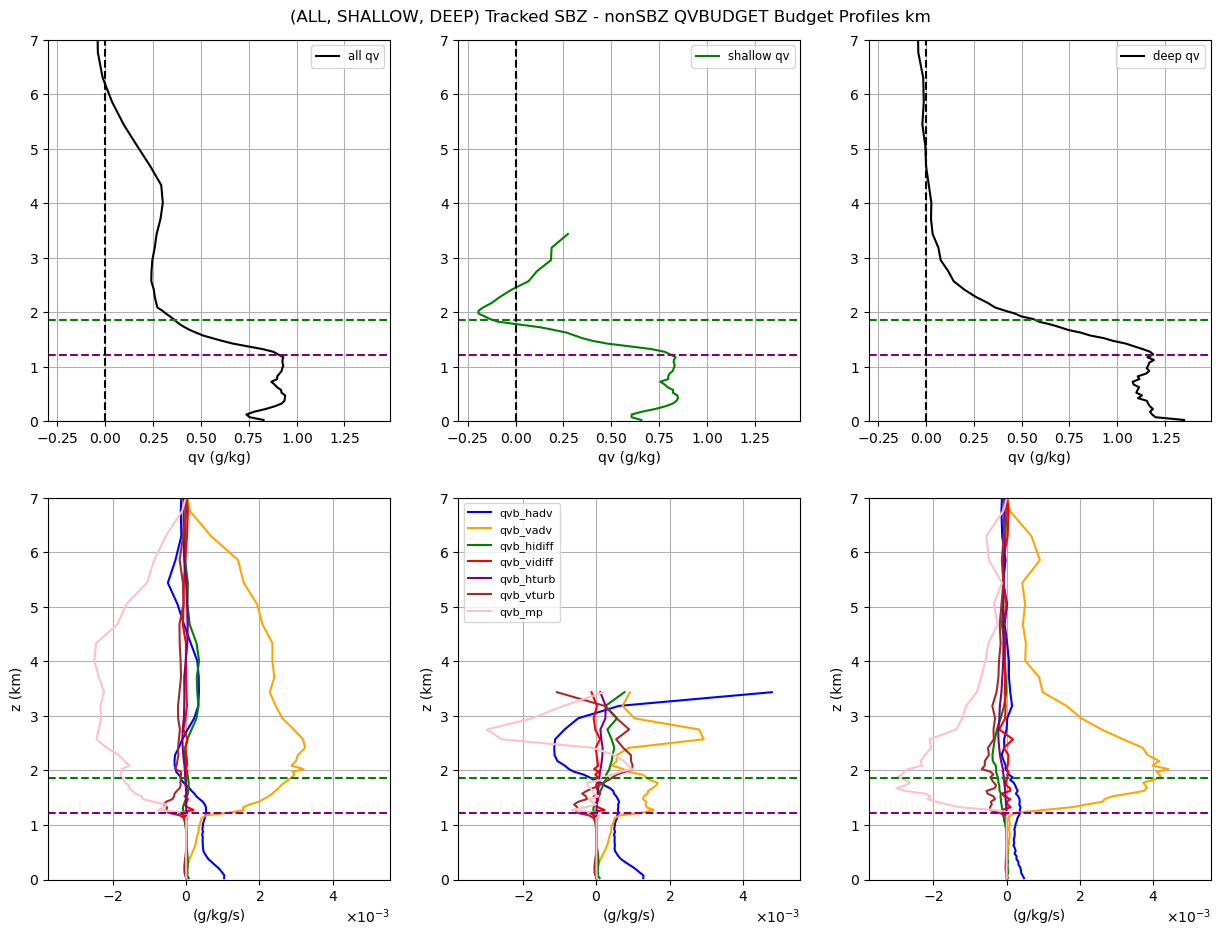

In [296]:
# SBZ minus nonSBZ QV BUDGETS
####################################################################
dim='1km'

#Uses Plotting Function 
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
plt.subplots_adjust(top=0.95)

fig.suptitle(f"(ALL, SHALLOW, DEEP) Tracked SBZ - nonSBZ QVBUDGET Budget Profiles km")
ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()

####################################################################
for type in ["all","shallow","deep"]:
    print(f'currently on type {type}')
        
    #Plotting function
    def plotting(out_var,axis,label,color):
        axis.plot(out_var[:,0],out_var[:,1],label=label,color=color)
        axis.grid(True)
    
    #Uses Averaged_Profiles Function
    vars = [
        'qv',
        'qvb_hadv',
        'qvb_vadv',
        'qvb_hidiff',
        'qvb_vidiff',
        'qvb_hturb',
        'qvb_vturb',
        'qvb_mp'
    ]

    for var in vars:
        globals()[f"profile_{var}1"] = globals()[f"SBZ_{type.upper()}_profile_array_{var.upper()}"]
    for var in vars:
        globals()[f"profile_{var}2"] = globals()[f"nonSBZ_{type.upper()}_profile_array_{var.upper()}"]
    
    colors = [
    'black',    
    'blue',     
    'orange',   
    'green',    
    'red',      
    'purple',   
    'brown',    
    'pink',     
    'grey',
    'cyan'
]

    for var in vars:
        globals()[f"out_{var}"]=average_difference(globals()[f"profile_{var}1"],globals()[f"profile_{var}2"])
        globals()[f"out_{var}"][:,0]*=1000

    if type=='all':
        axis=ax1
        plotting(out_qv,axis,label=f'{type} ' + vars[0],color=colors[0])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('qv (g/kg)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax4
    elif type=='shallow':
        axis=ax2
        plotting(out_qv,axis,label=f'{type} ' + vars[0],color=colors[3])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('qv (g/kg)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax5
    elif type=='deep':
        axis=ax3
        plotting(out_qv,axis,label=f'{type} ' + vars[0],color=colors[0])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('qv (g/kg)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax6
    for var,xlabel,color in zip(vars[1:],vars[1:],colors[1:]):
        plotting(globals()[f"out_{var}"],axis,label=xlabel,color=color)
        # axis.set_ylim(bottom=0,top=16)
        axis.set_ylabel('z (km)');
        axis.set_xlabel('(g/kg/s)')
        if type=='shallow':
            axis.legend(loc='upper left', fontsize=8) #add legend


#LIMITING Y AXIS
for ax in [ax1,ax2,ax3,ax4,ax5,ax6]:
    ax.set_ylim(bottom=0)
    #LIMITING YAXIS TO BELOW 7 KM
    if limit_y==True: 
        limit_axes_to_y(ax,y_min=0, y_max=7)   


#FIXING XAXES
fix_x_limits([ax1, ax2, ax3]);fix_y_limits([ax1, ax2, ax3])
fix_x_limits([ax4, ax5, ax6]);fix_y_limits([ax4, ax5, ax6])

# #MEAN LFC 
# for axis in [ax1,ax4]:
#     axis.axhline(np.mean((mean_LFC(ALL_SBZ_out_arr), mean_LFC(ALL_nonSBZ_out_arr))),color='blue',linestyle='dashed')
# for axis in [ax2,ax5]:
#     axis.axhline(np.mean((mean_LFC(SHALLOW_SBZ_out_arr), mean_LFC(SHALLOW_nonSBZ_out_arr))),color='blue',linestyle='dashed')
# for axis in [ax3,ax6]:
#     axis.axhline(np.mean((mean_LFC(DEEP_SBZ_out_arr), mean_LFC(DEEP_nonSBZ_out_arr))),color='blue',linestyle='dashed')

#MEAN CLOUD BASE
axs = fig.get_axes()
ax1, ax2, ax3, ax4, ax5, ax6 = axs
for axis in [ax1,ax2,ax3,ax4,ax5,ax6]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')
    axis.axhline(MeanLFC/1000,color='green',linestyle='dashed')

#SCIENTIFIC NOTATION
apply_scientific_notation([ax1,ax2,ax3,ax4, ax5, ax6])

#MIDDLE LINE
for axis in [ax1,ax2,ax3]:
    axis.axvline(0,color='k',linestyle='dashed')

#save plot
if dim=='1km':
    plt.savefig(dir+f'Project_Algorithms/plots/SBZminusnonSBZ_Tracked_QVBUDGET_profile.jpg', bbox_inches='tight', dpi=300) 
#limited

currently on type all
currently on type shallow
currently on type deep
(-1.9059540280451586, 2.079098559731989)
(0.0, 17.061249999981374)
(-0.050145680808761146, 0.040037827293475124)
(0.0, 17.061249999981374)


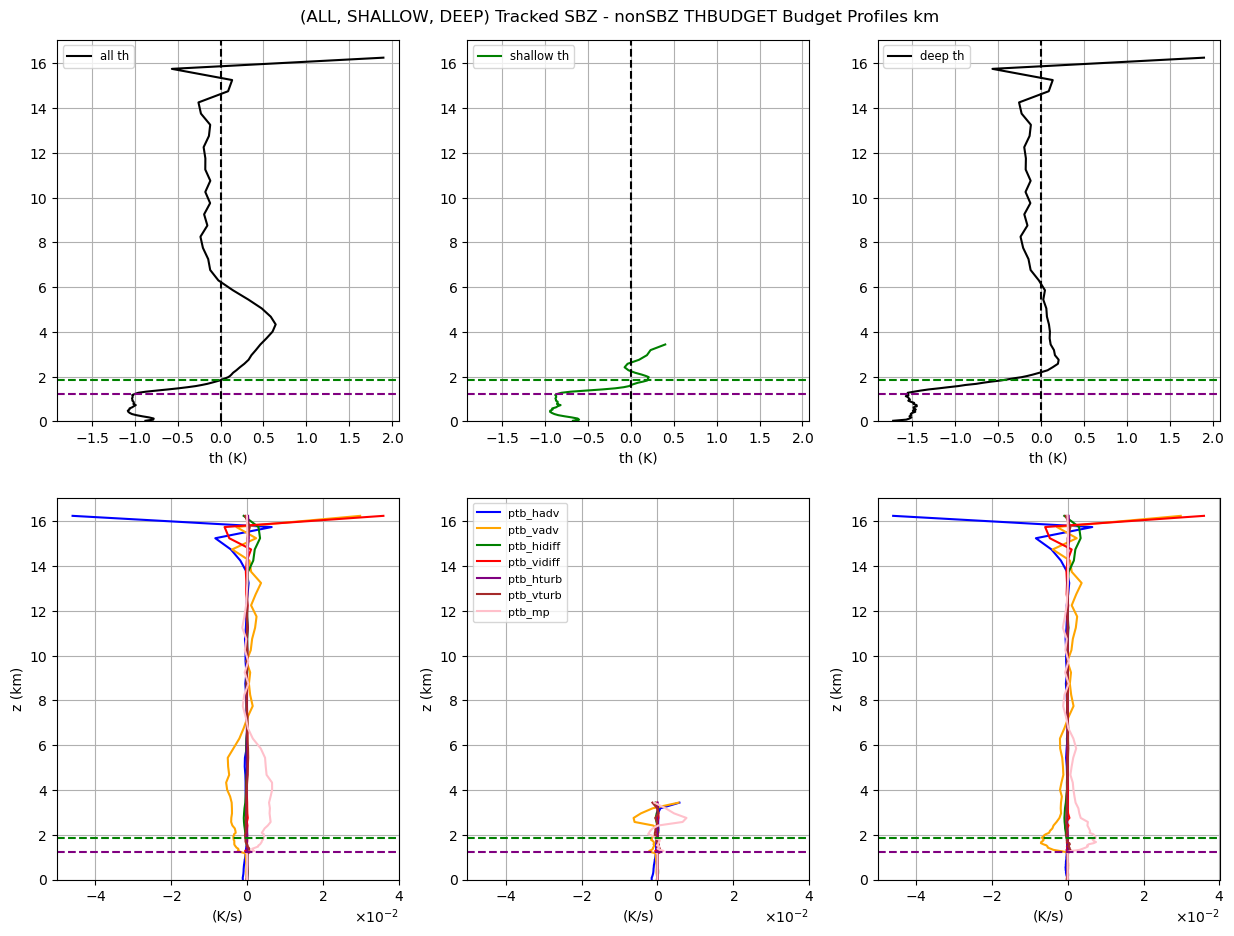

In [229]:
# SBZ minus nonSBZ TH BUDGETS

import h5py
####################################################################
dim='1km'

#Uses Plotting Function 
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
plt.subplots_adjust(top=0.95)

fig.suptitle(f"(ALL, SHALLOW, DEEP) Tracked SBZ - nonSBZ THBUDGET Budget Profiles km")
ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()

####################################################################
for type in ["all","shallow","deep"]:
    print(f'currently on type {type}')
        
    #Plotting function
    def plotting(out_var,axis,label,color):
        axis.plot(out_var[:,0],out_var[:,1],label=label,color=color)
        axis.grid(True)
    
    #Uses Averaged_Profiles Function
    vars = [
        'th',
        'ptb_hadv',
        'ptb_vadv',
        'ptb_hidiff',
        'ptb_vidiff',
        'ptb_hturb',
        'ptb_vturb',
        'ptb_mp'
    ]

    for var in vars:
        globals()[f"profile_{var}1"] = globals()[f"SBZ_{type.upper()}_profile_array_{var.upper()}"]
    for var in vars:
        globals()[f"profile_{var}2"] = globals()[f"nonSBZ_{type.upper()}_profile_array_{var.upper()}"]
        
    colors = [
    'black',    
    'blue',     
    'orange',   
    'green',    
    'red',      
    'purple',   
    'brown',    
    'pink',     
    'grey',
    'cyan'
]

    for var in vars:
        globals()[f"out_{var}"]=average_difference(globals()[f"profile_{var}1"],globals()[f"profile_{var}2"])
        # globals()[f"out_{var}"]=averaged_profiles(var)

    if type=='all':
        axis=ax1
        plotting(out_th,axis,label=f'{type} ' + vars[0],color=colors[0])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('th (K)')
        axis.legend(loc='upper left', fontsize='small'); #add legend
        axis=ax4
    elif type=='shallow':
        axis=ax2
        plotting(out_th,axis,label=f'{type} ' + vars[0],color=colors[3])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('th (K)')
        axis.legend(loc='upper left', fontsize='small'); #add legend
        axis=ax5
    elif type=='deep':
        axis=ax3
        plotting(out_th,axis,label=f'{type} ' + vars[0],color=colors[0])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('th (K)')
        axis.legend(loc='upper left', fontsize='small'); #add legend
        axis=ax6
    for var,xlabel,color in zip(vars[1:],vars[1:],colors[1:]):
        plotting(globals()[f"out_{var}"],axis,label=xlabel,color=color)
        # axis.set_ylim(bottom=0,top=16)
        axis.set_ylabel('z (km)');
        axis.set_xlabel('(K/s)')
        if type=='shallow':
            axis.legend(loc='upper left', fontsize=8); #add legend


#LIMITING Y AXIS
for ax in [ax1,ax2,ax3,ax4,ax5,ax6]:
    ax.set_ylim(bottom=0)
    #LIMITING YAXIS TO BELOW 7 KM
    if limit_y==True: 
        limit_axes_to_y(ax,y_min=0, y_max=7)   
        
#FIXING XAXES
fix_x_limits([ax1, ax2, ax3]);fix_y_limits([ax1, ax2, ax3])
fix_x_limits([ax4, ax5, ax6]);fix_y_limits([ax4, ax5, ax6])

# #MEAN LFC 
# for axis in [ax1,ax4]:
#     axis.axhline(np.mean((mean_LFC(ALL_SBZ_out_arr), mean_LFC(ALL_nonSBZ_out_arr))),color='blue',linestyle='dashed')
# for axis in [ax2,ax5]:
#     axis.axhline(np.mean((mean_LFC(SHALLOW_SBZ_out_arr), mean_LFC(SHALLOW_nonSBZ_out_arr))),color='blue',linestyle='dashed')
# for axis in [ax3,ax6]:
#     axis.axhline(np.mean((mean_LFC(DEEP_SBZ_out_arr), mean_LFC(DEEP_nonSBZ_out_arr))),color='blue',linestyle='dashed')

#MEAN CLOUD BASE
axs = fig.get_axes()
ax1, ax2, ax3, ax4, ax5, ax6 = axs
for axis in [ax1,ax2,ax3,ax4,ax5,ax6]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')
    axis.axhline(MeanLFC/1000,color='green',linestyle='dashed')


#SCIENTIFIC NOTATION
apply_scientific_notation([ax1, ax2, ax3,ax4,ax5,ax6])

#MIDDLE LINE
for axis in [ax1,ax2,ax3]:
    axis.axvline(0,color='k',linestyle='dashed')

#save plot
if dim=='1km':
    plt.savefig(dir+f'Project_Algorithms/plots/SBZminusnonSBZ_Tracked_THBUDGET_profile.jpg', bbox_inches='tight', dpi=300) 
#limited

In [230]:
#ColdPool
################################################################

In [297]:
data_type="Tracked_Properties"
type1='ColdPool'
dir3=dir+'Project_Algorithms/Tracked_Profiles/OUTPUT_FILES/'
filePath=dir3+f"{data_type}_"+f"{type1}_tracked_profiles_{res}_{t_res}_{Np_str}.h5"
key_list=[]
with h5py.File(filePath, 'r') as h5f:
    for key in h5f.keys():
        globals()[key] = h5f[key][:]
        if '_squares' not in key:
            key_list.append(key)

#CALCULATING STANDARD DEVIATION
for key in key_list:
    # globals()[key+f"_SE"]=ProfileStandardError(globals()[key],globals()[key+f"_squares"])
    globals()[key+f"_SE"]=ProfileStandardDeviation(globals()[key],globals()[key+f"_squares"])

#MULTIPLING QV BY 1000
for key in key_list:
    if 'Q' in key:
        globals()[key][:,0]*=1000
        globals()[key+f"_SE"][:,0]*=1000

ValueError: operands could not be broadcast together with shapes (31,) (79,) (31,) 

In [298]:
#*#*#
#IF SE NOT AVAILABLE, MAKE DUMMY VARIABLES
factor=1
for key in key_list:
    dummy=globals()[key].copy()
    dummy[:,0]=np.zeros(len(dummy[:,0]))
    dummy=dummy[dummy[:,1]>1]
    globals()[key+f"_SE"]=dummy

In [299]:
#NEEDED TO PLOT THE CORRECT DATA #*#*
data_type="Tracked_WQVTH_Budgets"

type1='ColdPool'
dir3=dir+'Project_Algorithms/Tracked_Profiles/OUTPUT_FILES/'
filePath=dir3+f"{data_type}_"+f"{type1}_tracked_profiles_{res}_{t_res}_{Np_str}.h5"
key_list=[]
with h5py.File(filePath, 'r') as h5f:
    for key in h5f.keys():
        globals()[key] = h5f[key][:]
        if '_squares' not in key:
            key_list.append(key)

#CALCULATING STANDARD DEVIATION
for key in key_list:
    # globals()[key+f"_SE"]=ProfileStandardError(globals()[key],globals()[key+f"_squares"])
    globals()[key+f"_SE"]=ProfileStandardDeviation(globals()[key],globals()[key+f"_squares"])

#MULTIPLING QV BY 1000
for key in key_list:
    if 'QVB' in key:
        globals()[key][:,0]*=1000
        globals()[key+f"_SE"][:,0]*=1000

ValueError: operands could not be broadcast together with shapes (31,) (79,) (31,) 

In [300]:
#*#*#
#IF SE NOT AVAILABLE, MAKE DUMMY VARIABLES
factor=1
for key in key_list:
    dummy=globals()[key].copy()
    dummy[:,0]=np.zeros(len(dummy[:,0]))
    dummy=dummy[dummy[:,1]>1]
    globals()[key+f"_SE"]=dummy

Currently on cloud type: all
Currently on cloud type: shallow
Currently on cloud type: deep
(-0.3740178533594171, 10.387717320054245)
(0.0, 17.586249999981373)
(-0.5515884412300527, 0.26456041645866873)
(0.0, 17.586249999981373)


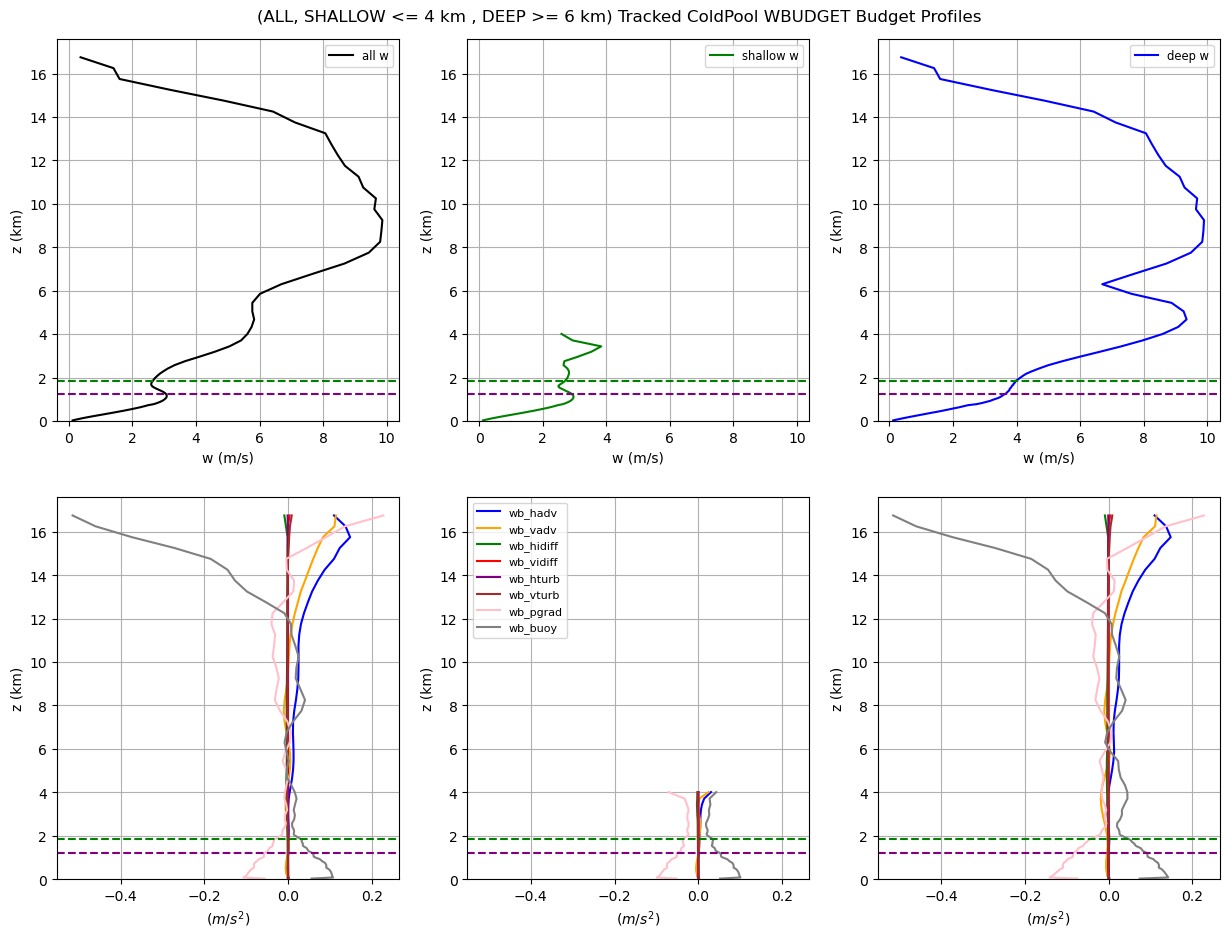

In [235]:
type1='ColdPool'
PlotBudgetProfiles(
    type1=type1,
    vars = [
    'w',
    'wb_hadv',
    'wb_vadv',
    'wb_hidiff',
    'wb_vidiff',
    'wb_hturb',
    'wb_vturb',
    'wb_pgrad',
    'wb_buoy'],
    var_unit='m/s',
    budget_unit=r'$m/s^2$',
    title_tag=type1,
    output_filename=dir + 'Project_Algorithms/plots/CL_Tracked_WBUDGET_profile.jpg',
    colors=[
        'black', 'blue', 'orange', 'green', 'red',
        'purple', 'brown', 'pink', 'grey', 'cyan'
    ]
)



Currently on cloud type: all
Currently on cloud type: shallow
Currently on cloud type: deep
(2.7351292378169134, 16.481178282469774)
(0.0, 7.0)
(-0.021113011296572205, 0.024130959693666593)
(0.0, 7.0)


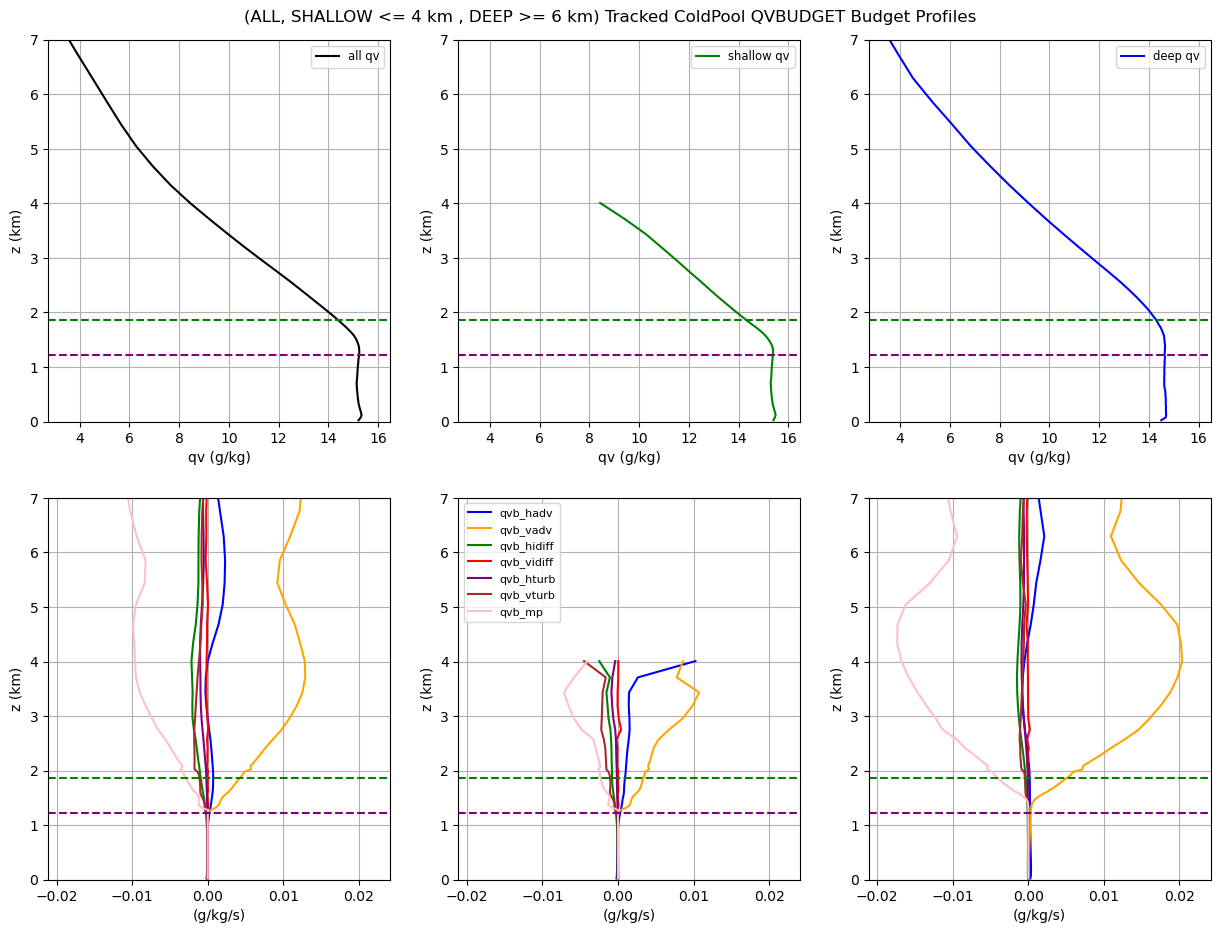

In [301]:
type1='ColdPool'
PlotBudgetProfiles(
    type1=type1,
    vars = [
        'qv',
        'qvb_hadv',
        'qvb_vadv',
        'qvb_hidiff',
        'qvb_vidiff',
        'qvb_hturb',
        'qvb_vturb',
        'qvb_mp'
    ],
    var_unit='g/kg',
    budget_unit='g/kg/s',
    title_tag=type1,
    output_filename=dir + 'Project_Algorithms/plots/CL_Tracked_WBUDGET_profile.jpg',
    colors=[
        'black', 'blue', 'orange', 'green', 'red',
        'purple', 'brown', 'pink', 'grey', 'cyan'
    ],
    min_value=0
)


Currently on cloud type: all
Currently on cloud type: shallow
Currently on cloud type: deep
(302.46163366353034, 370.3681561207395)
(0.0, 17.586249999981373)
(-0.2118302666076461, 0.12237023311734664)
(0.0, 17.586249999981373)


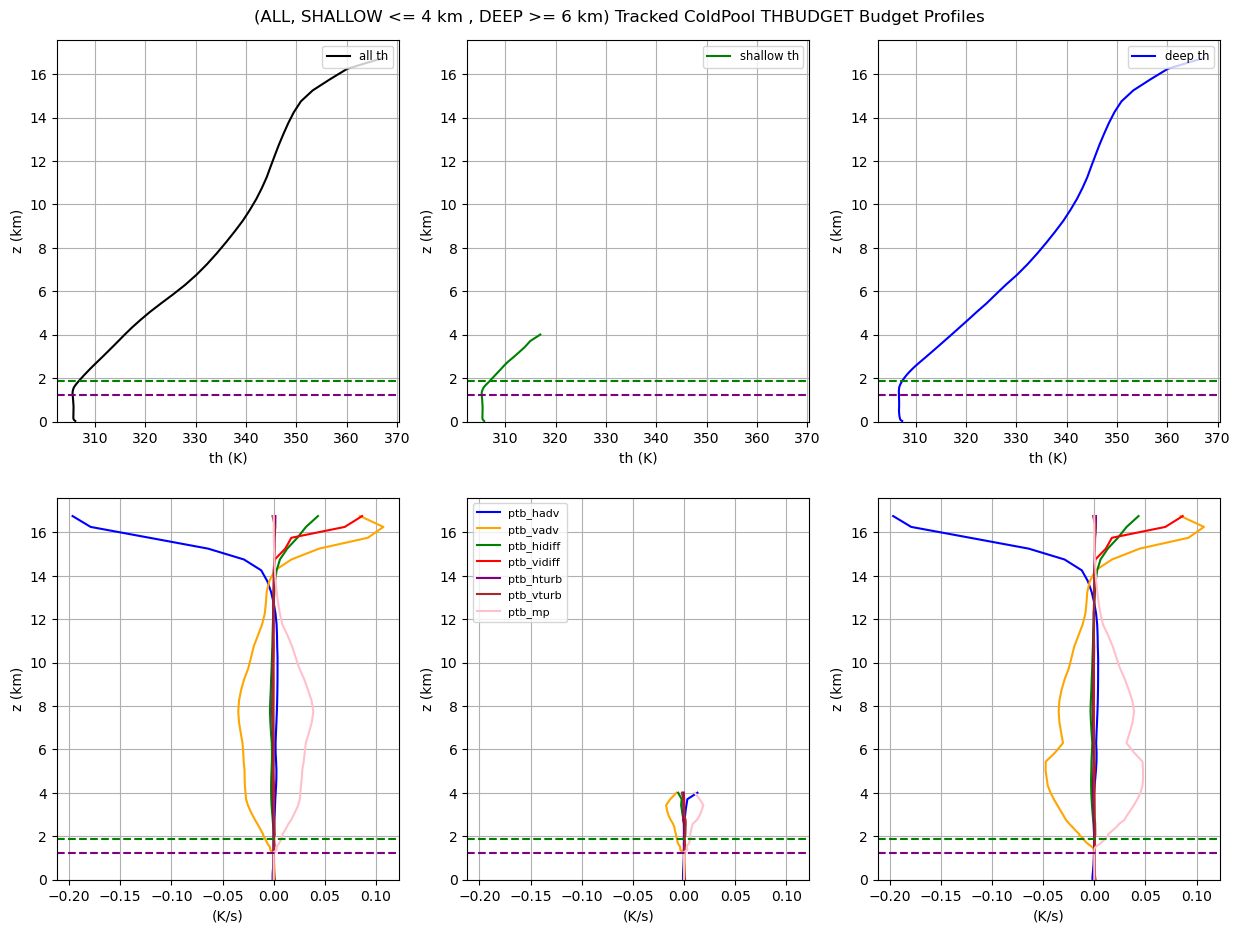

In [237]:
type1='ColdPool'
PlotBudgetProfiles(
    type1=type1,
    vars = [
        'th',
        'ptb_hadv',
        'ptb_vadv',
        'ptb_hidiff',
        'ptb_vidiff',
        'ptb_hturb',
        'ptb_vturb',
        'ptb_mp'
    ],
    var_unit='K',
    budget_unit='K/s',
    title_tag=type1,
    output_filename=dir + 'Project_Algorithms/plots/CL_Tracked_WBUDGET_profile.jpg',
    colors=[
        'black', 'blue', 'orange', 'green', 'red',
        'purple', 'brown', 'pink', 'grey', 'cyan'
    ]
)


In [238]:
# SBZ minus ColdPool
############################################

In [239]:
def average_difference(array1, array2):
    out_var_one=averaged_profiles(array1)
    out_var_two=averaged_profiles(array2)

    #masking out non matches
    second_col_one = out_var_one[:, 1]
    second_col_two = out_var_two[:, 1]
    mask_one = np.isin(second_col_one, second_col_two)
    mask_two = np.isin(second_col_two, second_col_one)
    
    out_var_one = out_var_one.copy()[mask_one]
    out_var_two = out_var_two.copy()[mask_two]
    
    diff=(out_var_one[:,0]-out_var_two[:,0])
    zs=out_var_one[:,1]

    out_profile=np.zeros((len(diff),2))

    out_profile[:,0]=diff;out_profile[:,1]=zs;
    return out_profile

currently on type all
currently on type shallow
currently on type deep
(-2.1918122872278643, 1.271576452356872)
(0.0, 17.061249999981374)
(-0.049904645952885955, 0.08151690359535212)
(0.0, 17.061249999981374)


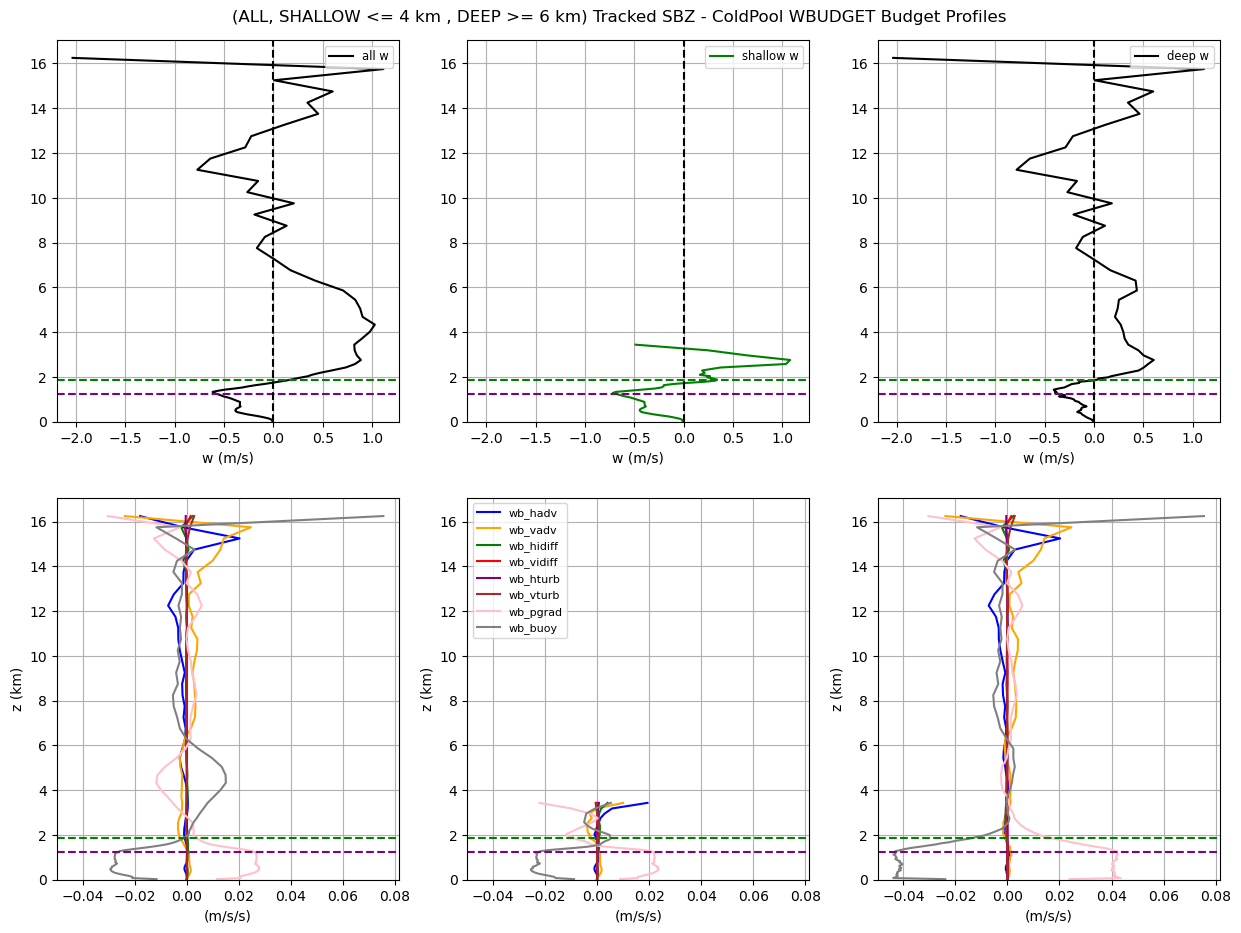

In [240]:
# SBZ minus ColdPool W BUDGET

import h5py
####################################################################
dim='1km'

#Uses Plotting Function 
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
plt.subplots_adjust(top=0.95)

fig.suptitle(f"(ALL, SHALLOW <= 4 km , DEEP >= 6 km) Tracked SBZ - ColdPool WBUDGET Budget Profiles")
ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()

####################################################################
for type in ["all","shallow","deep"]:
    print(f'currently on type {type}')

    #Plotting function
    def plotting(out_var,axis,label,color):
        axis.plot(out_var[:,0],out_var[:,1],label=label,color=color)
        axis.grid(True)
    
    #Uses Averaged_Profiles Function
    vars = [
    'w',
    'wb_hadv',
    'wb_vadv',
    'wb_hidiff',
    'wb_vidiff',
    'wb_hturb',
    'wb_vturb',
    'wb_pgrad',
    'wb_buoy'
]

    for var in vars:
        globals()[f"profile_{var}1"] = globals()[f"SBZ_{type.upper()}_profile_array_{var.upper()}"]
    for var in vars:
        globals()[f"profile_{var}2"] = globals()[f"ColdPool_{type.upper()}_profile_array_{var.upper()}"]
    
    colors = [
    'black',    
    'blue',     
    'orange',   
    'green',    
    'red',      
    'purple',   
    'brown',    
    'pink',     
    'grey',
    'cyan'
]

    for var in vars:
        globals()[f"out_{var}"]=average_difference(globals()[f"profile_{var}1"],globals()[f"profile_{var}2"])
        # globals()[f"out_{var}"]=averaged_profiles(var)
        

    if type=='all':
        axis=ax1
        plotting(out_w,axis,label=f'{type} ' + vars[0],color=colors[0])
        # axis.set_ylim(bottom=0,top=4.25)
        axis.set_xlabel('w (m/s)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax4
    if type=='shallow':
        axis=ax2
        plotting(out_w,axis,label=f'{type} ' + vars[0],color=colors[3])
        # axis.set_ylim(bottom=0,top=4.25)
        axis.set_xlabel('w (m/s)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax5
    if type=='deep':
        axis=ax3
        plotting(out_w,axis,label=f'{type} ' + vars[0],color=colors[0])
        # axis.set_ylim(bottom=0,top=4.25)
        axis.set_xlabel('w (m/s)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax6
    for var,xlabel,color in zip(vars[1:],vars[1:],colors[1:]):
        plotting(globals()[f"out_{var}"],axis,label=xlabel,color=color)
        # axis.set_ylim(bottom=0,top=4.25)
        axis.set_ylabel('z (km)');
        axis.set_xlabel('(m/s/s)')
        if type in ['shallow']:
            axis.legend(loc='upper left', fontsize=8); #add legend


#LIMITING Y AXIS
for ax in [ax1,ax2,ax3,ax4,ax5,ax6]:
    ax.set_ylim(bottom=0)
    #LIMITING YAXIS TO BELOW 7 KM
    if limit_y==True: 
        limit_axes_to_y(ax,y_min=0, y_max=7)   
        
#FIXING XAXES
fix_x_limits([ax1, ax2, ax3]);fix_y_limits([ax1, ax2, ax3])
fix_x_limits([ax4, ax5, ax6]);fix_y_limits([ax4, ax5, ax6])

#MEAN CLOUD BASE
axs = fig.get_axes()
ax1, ax2, ax3, ax4, ax5, ax6 = axs
for axis in [ax1,ax2,ax3,ax4,ax5,ax6]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')
    axis.axhline(MeanLFC/1000,color='green',linestyle='dashed')


#MIDDLE LINE
for axis in [ax1,ax2,ax3]:
    axis.axvline(0,color='k',linestyle='dashed')


#save plot
if dim=='1km':
    plt.savefig(dir+f'Project_Algorithms/plots/SBZminusColdPool_Tracked_WBUDGET_profile.jpg', bbox_inches='tight', dpi=300) 
#- Limited

currently on type all
currently on type shallow
currently on type deep
(-0.2988224508450963, 1.4884993122119996)
(0.0, 7.0)
(-0.003760741508912187, 0.00556029619610861)
(0.0, 7.0)


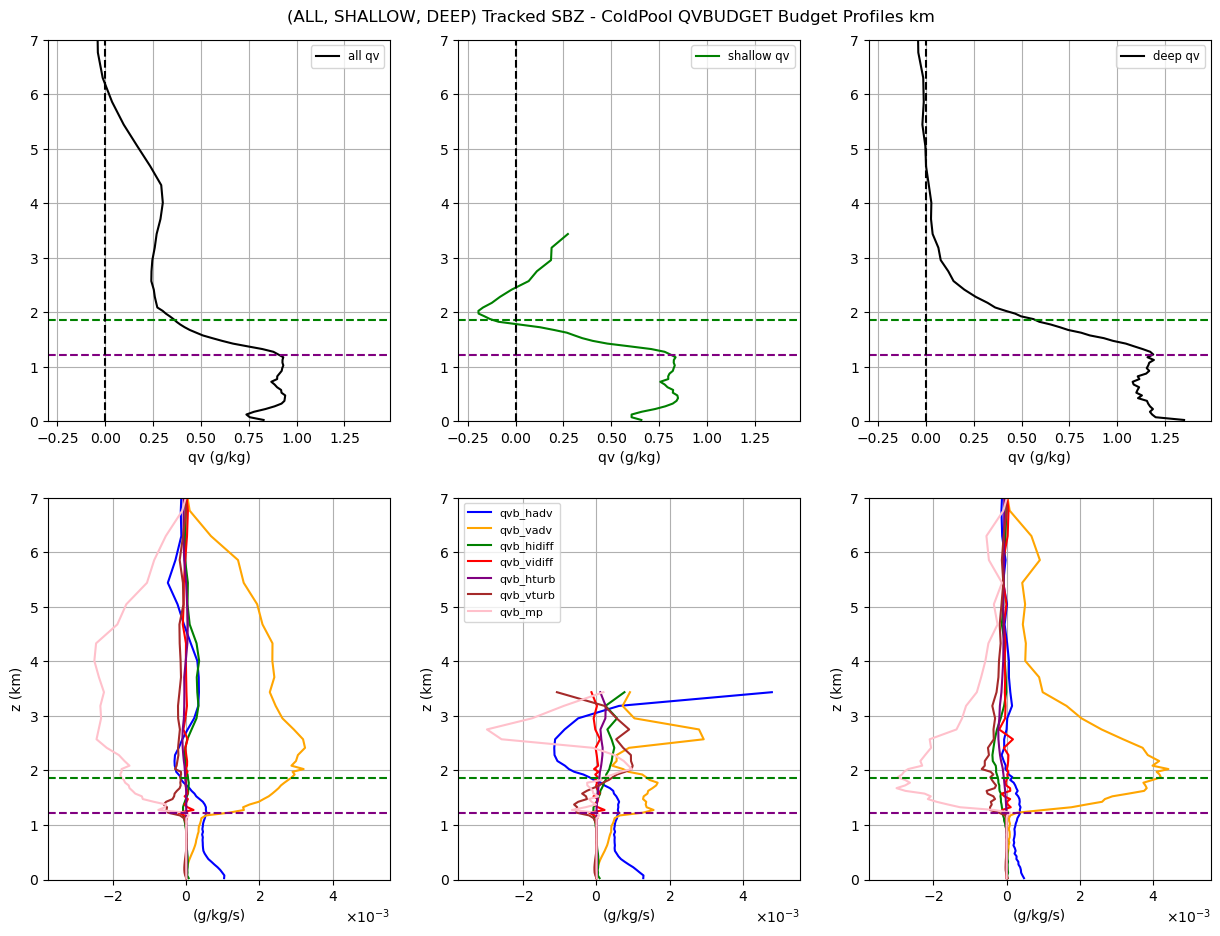

In [302]:
# SBZ minus ColdPool QV BUDGETS
####################################################################
dim='1km'

#Uses Plotting Function 
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
plt.subplots_adjust(top=0.95)

fig.suptitle(f"(ALL, SHALLOW, DEEP) Tracked SBZ - ColdPool QVBUDGET Budget Profiles km")
ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()

####################################################################
for type in ["all","shallow","deep"]:
    print(f'currently on type {type}')
        
    #Plotting function
    def plotting(out_var,axis,label,color):
        axis.plot(out_var[:,0]*1000,out_var[:,1],label=label,color=color)
        axis.grid(True)
    
    #Uses Averaged_Profiles Function
    vars = [
        'qv',
        'qvb_hadv',
        'qvb_vadv',
        'qvb_hidiff',
        'qvb_vidiff',
        'qvb_hturb',
        'qvb_vturb',
        'qvb_mp'
    ]

    for var in vars:
        globals()[f"profile_{var}1"] = globals()[f"SBZ_{type.upper()}_profile_array_{var.upper()}"]
    for var in vars:
        globals()[f"profile_{var}2"] = globals()[f"ColdPool_{type.upper()}_profile_array_{var.upper()}"]
    
    colors = [
    'black',    
    'blue',     
    'orange',   
    'green',    
    'red',      
    'purple',   
    'brown',    
    'pink',     
    'grey',
    'cyan'
]

    for var in vars:
        globals()[f"out_{var}"]=average_difference(globals()[f"profile_{var}1"],globals()[f"profile_{var}2"])


    if type=='all':
        axis=ax1
        plotting(out_qv,axis,label=f'{type} ' + vars[0],color=colors[0])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('qv (g/kg)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax4
    elif type=='shallow':
        axis=ax2
        plotting(out_qv,axis,label=f'{type} ' + vars[0],color=colors[3])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('qv (g/kg)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax5
    elif type=='deep':
        axis=ax3
        plotting(out_qv,axis,label=f'{type} ' + vars[0],color=colors[0])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('qv (g/kg)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax6
    for var,xlabel,color in zip(vars[1:],vars[1:],colors[1:]):
        plotting(globals()[f"out_{var}"],axis,label=xlabel,color=color)
        # axis.set_ylim(bottom=0,top=16)
        axis.set_ylabel('z (km)');
        axis.set_xlabel('(g/kg/s)')
        if type=='shallow':
            axis.legend(loc='upper left', fontsize=8) #add legend


#LIMITING Y AXIS
for ax in [ax1,ax2,ax3,ax4,ax5,ax6]:
    ax.set_ylim(bottom=0)
    #LIMITING YAXIS TO BELOW 7 KM
    if limit_y==True: 
        limit_axes_to_y(ax,y_min=0, y_max=7)   


#FIXING XAXES
fix_x_limits([ax1, ax2, ax3]);fix_y_limits([ax1, ax2, ax3])
fix_x_limits([ax4, ax5, ax6]);fix_y_limits([ax4, ax5, ax6])

#MEAN CLOUD BASE
axs = fig.get_axes()
ax1, ax2, ax3, ax4, ax5, ax6 = axs
for axis in [ax1,ax2,ax3,ax4,ax5,ax6]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')
    axis.axhline(MeanLFC/1000,color='green',linestyle='dashed')

#SCIENTIFIC NOTATION
apply_scientific_notation([ax4, ax5, ax6])

#MIDDLE LINE
for axis in [ax1,ax2,ax3]:
    axis.axvline(0,color='k',linestyle='dashed')

#save plot
if dim=='1km':
    plt.savefig(dir+f'Project_Algorithms/plots/SBZminusColdPool_Tracked_QVBUDGET_profile.jpg', bbox_inches='tight', dpi=300) 
#limited

currently on type all
currently on type shallow
currently on type deep
(-1.9059540280451586, 2.079098559731989)
(0.0, 17.061249999981374)
(-0.050145680808761146, 0.040037827293475124)
(0.0, 17.061249999981374)


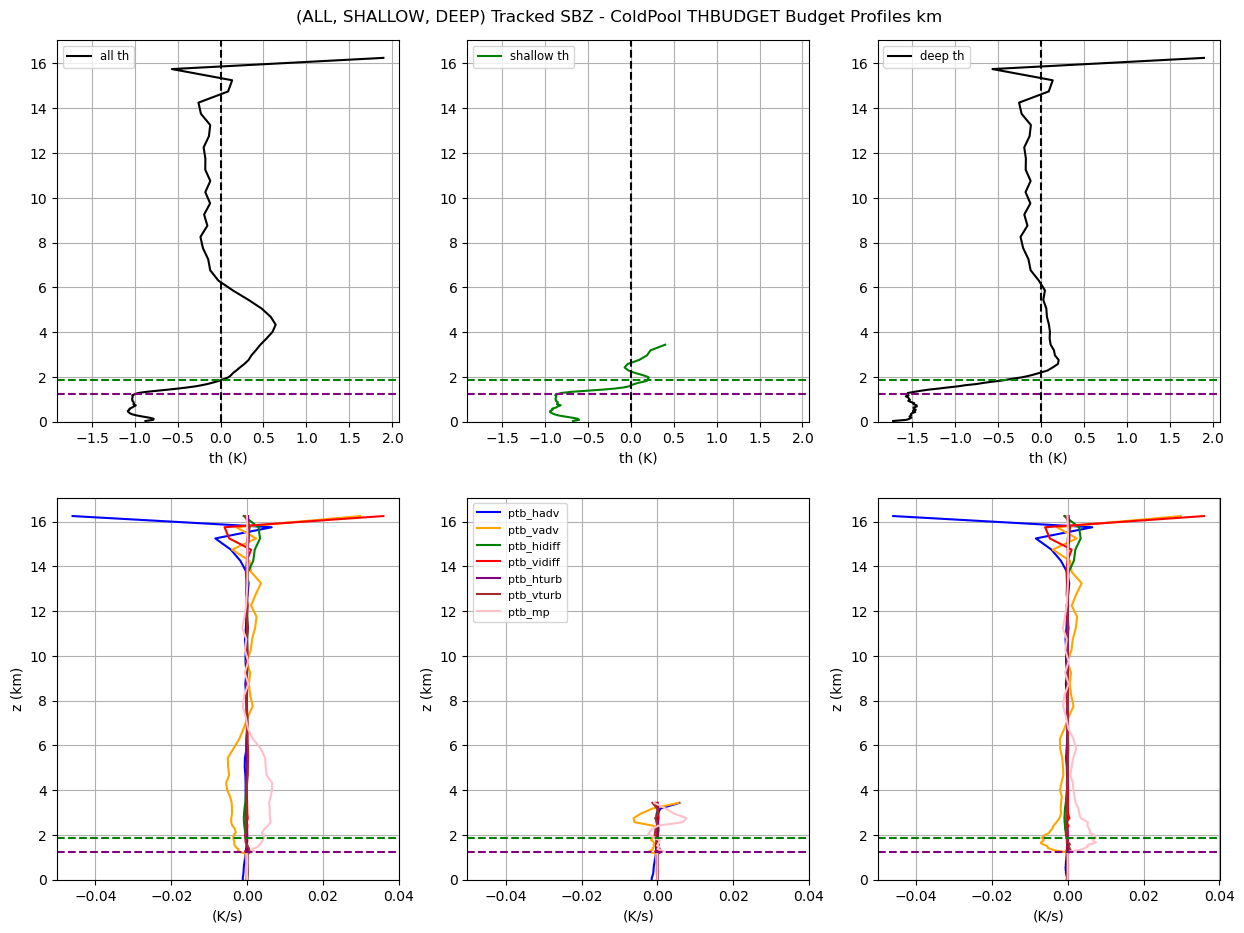

In [242]:
# SBZ minus ColdPool TH BUDGETS

import h5py
#Produced averaged profiles for plotting

####################################################################
dim='1km'

#Uses Plotting Function 
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
plt.subplots_adjust(top=0.95)

fig.suptitle(f"(ALL, SHALLOW, DEEP) Tracked SBZ - ColdPool THBUDGET Budget Profiles km")
ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()

####################################################################
for type in ["all","shallow","deep"]:
    print(f'currently on type {type}')

    #Plotting function
    def plotting(out_var,axis,label,color):
        axis.plot(out_var[:,0],out_var[:,1],label=label,color=color)
        axis.grid(True)
    
    #Uses Averaged_Profiles Function
    vars = [
        'th',
        'ptb_hadv',
        'ptb_vadv',
        'ptb_hidiff',
        'ptb_vidiff',
        'ptb_hturb',
        'ptb_vturb',
        'ptb_mp'
    ]

    for var in vars:
        globals()[f"profile_{var}1"] = globals()[f"SBZ_{type.upper()}_profile_array_{var.upper()}"]
    for var in vars:
        globals()[f"profile_{var}2"] = globals()[f"ColdPool_{type.upper()}_profile_array_{var.upper()}"]
    
    colors = [
    'black',    
    'blue',     
    'orange',   
    'green',    
    'red',      
    'purple',   
    'brown',    
    'pink',     
    'grey',
    'cyan'
]

    for var in vars:
        globals()[f"out_{var}"]=average_difference(globals()[f"profile_{var}1"],globals()[f"profile_{var}2"])
        # globals()[f"out_{var}"]=averaged_profiles(var)

    if type=='all':
        axis=ax1
        plotting(out_th,axis,label=f'{type} ' + vars[0],color=colors[0])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('th (K)')
        axis.legend(loc='upper left', fontsize='small'); #add legend
        axis=ax4
    elif type=='shallow':
        axis=ax2
        plotting(out_th,axis,label=f'{type} ' + vars[0],color=colors[3])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('th (K)')
        axis.legend(loc='upper left', fontsize='small'); #add legend
        axis=ax5
    elif type=='deep':
        axis=ax3
        plotting(out_th,axis,label=f'{type} ' + vars[0],color=colors[0])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('th (K)')
        axis.legend(loc='upper left', fontsize='small'); #add legend
        axis=ax6
    for var,xlabel,color in zip(vars[1:],vars[1:],colors[1:]):
        plotting(globals()[f"out_{var}"],axis,label=xlabel,color=color)
        # axis.set_ylim(bottom=0,top=16)
        axis.set_ylabel('z (km)');
        axis.set_xlabel('(K/s)')
        if type=='shallow':
            axis.legend(loc='upper left', fontsize=8); #add legend


#LIMITING Y AXIS
for ax in [ax1,ax2,ax3,ax4,ax5,ax6]:
    ax.set_ylim(bottom=0)
    #LIMITING YAXIS TO BELOW 7 KM
    if limit_y==True: 
        limit_axes_to_y(ax,y_min=0, y_max=7)   


#FIXING XAXES
fix_x_limits([ax1, ax2, ax3]);fix_y_limits([ax1, ax2, ax3])
fix_x_limits([ax4, ax5, ax6]);fix_y_limits([ax4, ax5, ax6])


#MEAN CLOUD BASE
axs = fig.get_axes()
ax1, ax2, ax3, ax4, ax5, ax6 = axs
for axis in [ax1,ax2,ax3,ax4,ax5,ax6]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')
    axis.axhline(MeanLFC/1000,color='green',linestyle='dashed')


#SCIENTIFIC NOTATION
apply_scientific_notation([ax1, ax2, ax3])

#MIDDLE LINE
for axis in [ax1,ax2,ax3]:
    axis.axvline(0,color='k',linestyle='dashed')

#save plot
if dim=='1km':
    plt.savefig(dir+f'Project_Algorithms/plots/SBZminusColdPool_Tracked_THBUDGET_profile.jpg', bbox_inches='tight', dpi=300) 
#limited